# Activation analysis — persona self-recognition

This notebook is the **analysis layer**. It reads activations that two earlier
phases already captured and saved, joins them to a table of trial metadata, and
turns them into measures. It never re-runs the model (except the optional causal
experiment, exp14). Nothing here changes how activations were captured or how the
behavioral evaluation was scored.

## The setup in one paragraph

We have a set of **personas** (each a system prompt that gives the model a
character, e.g. a suppressed assistant, a near-twin, a sandbagger). Personas fall
into four **categories**: *suppression*, *near-twin*, *calibration*, *confound*.
Two capture phases produced the data:

- **Generation phase** — each persona writes text on neutral tasks. We saved the
  model's internal state while it wrote. This is where a persona's "fingerprint"
  comes from.
- **Evaluation phase** — the model is shown text and asked an authorship
  question ("which of these did *you* write?", "did you write this?"). Each such
  question is a **trial**, and trials come in 12 **cases** that vary the framing
  (one text vs two, with/without a persona description, self vs third-party, …).
  We saved the model's internal state at several named token positions during each
  trial, plus its answer and confidence.

## Named activation positions (the raw material)

Every saved activation is one `[n_layers, hidden]` vector — the residual stream at
**one token position**, at every captured layer. The experiments below are built
almost entirely from these positions:

| name in code | token position | what it represents |
|---|---|---|
| `DECISION` (`final_prompt_token_before_answer`) | the last token before the model emits A/B | the model's state **at the moment of judgment** |
| `PRE_TEXT` (`pre_text_token`) | just before any candidate text is shown | the model's **prior / leaning** before seeing evidence |
| `TEXT1_MEAN` / `TEXT2_MEAN` (`text1_mean`/`text2_mean`) | averaged over all tokens of each candidate text | the **reading-time** state for each text |
| `GEN_TEXT_MEAN` (`generated_text_mean`, generation phase) | averaged over the tokens the persona itself wrote | the persona's **behavior fingerprint** |
| `PERSONA_PROMPT_MEAN` / `PERSONA_PROMPT_FINAL` | over the persona's system-prompt tokens | the persona's **prompt-state** (leaks the prompt text — used only for drift, never as a recognition signal) |

Everything is computed **per layer** (we never pool layers together), in fp32, and
we save only small results. Persona **category** and **case/condition** are always
kept as grouping keys — nothing is silently averaged across them.

## How a "self-recognition direction" is built (the recurring trick)

Most experiments reduce to: take a population of activations split into two
groups, and define the **direction** = `mean(group A) − mean(group B)`. Projecting
any new activation onto that unit direction gives a scalar "how much group-A-like
is this." We then score that scalar on **held-out** trials with **AUROC** (or d′),
with **bootstrap confidence intervals**. Contrast directions are always built on a
TRAIN split and evaluated on trials the direction never saw.

## What each experiment does (plain language)

- **exp01 — Persona fingerprints (building block).** Builds a per-persona
  "fingerprint" vector from how the model processes that persona's own writing.
  The raw material many later experiments stand on.
- **exp04 — Boring explanations to rule out (building block).** Builds the "about
  to answer A vs B" and "answer points at text1 vs text2" directions, so later
  experiments can check the self-recognition signal isn't secretly one of these.
- **exp02 — Is there a "this is mine" direction? (headline).** Finds a direction
  that separates *reading my own text* from *reading someone else's*, and checks
  the signal survives removing the persona's writing style.
- **exp03 — Who actually recognises?** A plain accuracy table (no activations)
  showing which cases/personas can tell their own text apart — i.e. where a
  signal should even exist.
- **exp05 — One shared "mine" direction, or one per persona?** Compares the
  self-rec directions across personas, and asks whether recognising yourself is
  the same as detecting your own style.
- **exp06 — Bias vs evidence.** Does a persona lean "it's mine" *before* reading
  the text (a prior), or only *after* reading it (evidence uptake)?
- **exp07 — When does recognition happen?** Tracks the "mine" signal from
  before-text → while-reading → answer, to see if it builds up during reading or
  only appears at answer time.
- **exp08 — Where is authorship encoded?** Probes each layer to find where "self
  vs other" is readable but the writing style / identity is *not*.
- **exp09 — Real recognition vs confabulation.** Among confident "this is mine"
  claims, can we separate the correct ones from the made-up ones inside the
  activations?
- **exp10 — Does it generalise across tasks?** Trains the "mine" detector on one
  kind of task and tests it on others — general mechanism or task-specific trick?
- **exp11 — Same mechanism as judging others?** Compares the internal geometry of
  "which one is mine" against "which *other* persona wrote which".
- **exp12 — Does the persona drift?** While reading someone else's text, does the
  model start to "become" that other persona?
- **exp13 — Do deceptive personas cluster?** Groups personas purely by fingerprint
  to see if hidden-goal personas (sandbagger, sycophant) land together, with
  historians as the control.
- **exp14 — Causal test.** Actually edits the "mine" direction in a live forward
  pass; if removing it breaks recognition, the direction was doing real work.

## Reading the result scales (important — the numbers aren't all on the same scale)

Four kinds of number show up. Knowing the chance level and range for each is the
difference between "0.4 is bad" and "0.4 is well above chance":

- **AUROC** (exp02, exp08 author/position, exp09, exp10). Range 0–1.
  **0.5 = chance / no signal**; 1.0 = perfect separation; below 0.5 means the
  direction points the wrong way. Rough reading: 0.55–0.6 weak, 0.6–0.7 moderate,
  0.7–0.85 strong, >0.85 very strong. Shaded bands are 95% bootstrap CIs — if a
  band includes 0.5, treat that layer as "no reliable signal".
- **Balanced accuracy** (exp08 persona-identity & task-family curves). Range 0–1,
  but **chance is 1 / number-of-classes, NOT 0.5** — e.g. ~0.12 for 8 personas,
  ~0.25 for 4 task families. So a persona-identity score of 0.4 is *well above*
  chance even though it sits below the 0.5 gridline. (The 0.5 line on the exp08
  plot is the chance line for the *AUROC* curves only.)
- **Cosine** (exp01, exp04, exp05, exp09, exp11, exp13). Range −1 to +1: 0 =
  unrelated (orthogonal), +1 = identical direction, −1 = opposite. In ~4096-dim
  activation space two *random* vectors sit near 0 with spread only ~±0.02, so even
  0.1–0.3 is a real, modest alignment; >0.5 is strong; >0.8 is nearly the same
  direction.
- **Raw projection scalars** (exp06, exp07, exp12). These are plain dot products of
  an activation with a *unit* direction — the signed length of the activation along
  that direction, **in the same arbitrary units as the residual stream**. There is
  **no "1.0 = good" here and no fixed zero**, and crucially the residual-stream norm
  **grows with layer depth** in Llama, so these projections drift upward in late
  layers *even with no change in content*. That alone explains a curve climbing to
  ~2.0 at the final layers — it is not "twice as much" of anything. **Only read
  them comparatively:** the sign, the gap between conditions/categories at the
  *same* layer, and the change across positions or vs a baseline. "+2.0 for
  suppression vs +0.3 for calibration at the same layer" is meaningful; a bare
  "2.0" is not. (exp14 is the exception below — its y-axis is a real probability.)

## The one knob

Set `RUN_NAME` below to the run you want to analyse (the `run_name` from
`self_recognition_config.yaml`, e.g. `personacat_v1`). That name is the R2 prefix
both capture phases live under; `load_dataset` fetches and joins them.

**Storage note.** The brief calls the store "Zarr"; this repo shards into
`safetensors` (fp16) + a `metadata.parquet` table (R2-mirrored). The reader
(`analyze_activations_helpers`) hides that detail.

## Experiment map (also in `analyze_activations_README.md`)

- *Enabling / control:* exp01 (persona fingerprints), exp03 (behavioral
  baseline), exp04 (nuisance directions), exp11 (cross-case mechanism).
- *Access / introspection:* exp02, exp05, exp06, exp07, exp08, exp09, exp10,
  exp14.
- *Depth:* exp12 (persona switching), exp13 (hidden-goal clustering).

**Build order:** exp01 and exp04 are prerequisites; exp14 (causal) runs last. The
suite runner at the bottom respects this; individual cells call `dep()` to
materialise any prerequisite on demand.


In [1]:
import sys
from pathlib import Path

# Put the repo root on the path so `core` / `experiments` import from anywhere.
ROOT = Path.cwd()
while not (ROOT / "core").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiments.self_recognition import analyze_activations_helpers as H
print("helpers loaded from", H.__file__)

helpers loaded from /Users/daylight/dev/code/persona_introspection/experiments/self_recognition/analyze_activations_helpers.py


In [2]:

# ── THE ONE KNOB ─────────────────────────────────────────────────────────────
RUN_NAME = "personacat_v1"          # ← the run_name from self_recognition_config.yaml

# cfg = H.AnalysisConfig(
#     run_name=RUN_NAME,
#     model_name="meta-llama/Llama-3.1-8B-Instruct",
#     task="persona_category",        # locates the local eval trial table (exp14 only)
#     dry_run=False,                   # ← flip to False for the full run
#     confident_threshold=0.60,
#     train_frac=0.60,
#     n_bootstrap=1000,
#     seed=0,
#     primary_case="case7",           # ideal self-rec source; auto-falls back to a present case
#     comparison_case="case5",
#     enable_steering=False,          # exp14 only: needs a GPU + the model + local trial table
#     # DISK CONTROL (laptop): see exact size first, then fetch only some eval cases:
#     #   metadata_only=True,            # index/metadata only (pair with H.estimate_size)
#     #   download_cases=("case1", "case12"),  # fetch only these eval cases' tensors
# )

cfg = H.AnalysisConfig(
    run_name=RUN_NAME,
    model_name="meta-llama/Llama-3.1-8B-Instruct",
    task="persona_category",
    dry_run=False,                   # ← the one that actually matters
    confident_threshold=0.60,        # keep, but see note
    train_frac=0.60,                 # keep
    n_bootstrap=2000,                # bump from 1000 — cheap, tightens CIs on small access cells
    seed=0,
    primary_case="case7",            # keep — at full scale this should stop falling back
    comparison_case="case5",
    enable_steering=False,           # see below — flip to True in a separate GPU run
    # metadata_only / download_cases: leave OFF (commented) so it fetches all tensors
)

STORE = {}   # results cache: later experiments consume earlier ones (exp02 needs exp04, ...)

def run_cell(key, plot=None, recompute=False):
    """Run/load one experiment into STORE (reusing a cached result on disk unless
    recompute=True) and optionally plot it. No-op until the data is loaded."""
    if "ds" not in globals() or ds is None:
        print(f"(define-only: load the dataset cell first, then re-run {key})")
        return None
    res = H.cached_run(ds, cfg, key, STORE, recompute=recompute)
    if plot is not None:
        try:
            plot(res); plt.show()
        except Exception as e:
            print("plot skipped:", e)
    return res

def dep(store, key):
    """Materialise a prerequisite experiment's result (from memory, disk cache, or
    by computing it) so a single cell can be run out of order."""
    return H.cached_run(ds, cfg, key, store)

### Check download size first (optional)

Fetches only the tiny index/metadata (no tensors) and prints the exact GB of
the full download. On a small disk, set `cfg.download_cases = (...)` (or
`cfg.metadata_only = True`) before the load cell below.

In [3]:
_ = H.estimate_size(cfg)   # tiny: index/metadata only, no tensors downloaded

→ destination: /Users/daylight/dev/code/persona_introspection/experiments/self_recognition/results/activation_analysis/personacat_v1/data
  listing R2 objects …
  0 file(s) to fetch (0.00 GB); 68 already present (0.01 GB) — skipped.
FULL download size estimate (tensors only; metadata already fetched):
  generation : 380 ids, 1900 tensors, 9L x 4096h -> 0.14 GB
  evaluation : 24152 ids, 278944 tensors, 9L x 4096h -> 20.57 GB
  TOTAL: 20.71 GB  (restrict with cfg.download_cases=(...) to fetch only some eval cases)


In [4]:
# Fetch (from R2 if not cached) + read both phases, join to metadata, tag categories.
ds = H.load_dataset(cfg)
H.summarize(ds)

→ destination: /Users/daylight/dev/code/persona_introspection/experiments/self_recognition/results/activation_analysis/personacat_v1/data
  listing R2 objects …
  0 file(s) to fetch (0.00 GB); 100 already present (16.34 GB) — skipped.
run_name           : personacat_v1
layers (captured)  : [4, 6, 8, 12, 14, 16, 20, 24, 31]
eval trials        : 24152  | gen texts: 380
eval captures      : ['active_system_prompt_final', 'assistant_header_token', 'final_prompt_token_before_answer', 'other_description_1_mean', 'other_description_2_mean', 'other_description_mean', 'pre_description_token', 'pre_text_token', 'text1_final', 'text1_last10_mean', 'text1_mean', 'text2_final', 'text2_last10_mean', 'text2_mean']
gen  captures      : ['generated_text_last10_mean', 'generated_text_mean', 'generation_prompt_final', 'persona_prompt_final', 'persona_prompt_mean']

eval rows by case × system_prompt_present:
case    system_prompt_present
case1   True                     3000
case10  False                 

## Shared experiment-level helpers

A few small pieces that several experiments reuse. These are genuine *analysis
choices* (not generic plumbing), so they live here in one place to stay
consistent:

- **`pick_self_case`** — picks the cleanest self-recognition case that is actually
  present in this run (ideally case7: active persona, no description, so the answer
  needs no decoding).
- **`style_direction`** — the persona **style / identity subspace** at each layer:
  the top-k principal directions of the persona-behavior vectors. exp02 *removes*
  this (to ask whether self-recognition is more than writing style) and exp09
  *reports* against it; defining it once keeps both consistent.
- **answer-semantics decoders** (`_answer_key`, `_chose_self`, `_pointed_slot`, …)
  — read each trial's `answer_order` (e.g. `A=text1`) to translate the model's
  raw "A"/"B" into what it actually meant: *did it pick its own text? which
  physical slot did it point at?*
- **`_decision_self_dirs`** — builds the decision-token "self" direction per
  persona (used by exp02).


In [5]:
def pick_self_case(ds, cfg):
    '''The cleanest self-recognition case PRESENT in this run. case7 (active,
    no description) is ideal; case1 (single-text, active, no description) is also
    decode-free; case12 mirrors case7 over calibration personas.'''
    present = set(ds.eval_meta["case"].unique()) if not ds.eval_meta.empty else set()
    for c in [cfg.primary_case, "case7", "case1", "case12", "case3"]:
        if c in present:
            return c
    return sorted(present)[0] if present else None


def style_direction(ds, cfg, k=8):
    '''Persona STYLE/IDENTITY subspace per layer: the top-k principal directions of
    the persona-behavior vectors (a single PC1 is far too weak; identity is many-
    dimensional). Returns [L, k, H]; remove with H.project_out_subspace. Shared by
    exp02 (remove) and exp09 (report), so the choice stays consistent.'''
    gm = H.gen_view(ds, cfg, neutral_only=True)
    behav = {}
    for p, g in gm.groupby('persona'):
        arr, _ = H.stack_gen(ds, g, H.GEN_TEXT_MEAN)
        if len(arr):
            behav[p] = arr.mean(0)
    if len(behav) < 2:
        return None
    M = np.stack(list(behav.values()))            # [P, L, H]
    return np.stack([H.top_principal_components(M[:, i, :], k) for i in range(M.shape[1])])


def multiclass_balacc(Xtr, ytr, Xte, yte):
    '''Balanced accuracy of an L2 multinomial logistic probe (multiclass targets
    where AUROC is awkward). NaN if a split lacks >=2 classes.'''
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import balanced_accuracy_score
    ytr = np.asarray(ytr); yte = np.asarray(yte)
    if len(set(ytr.tolist())) < 2 or len(set(yte.tolist())) < 2:
        return float("nan")
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=2000).fit(sc.transform(Xtr), ytr)
    return float(balanced_accuracy_score(yte, clf.predict(sc.transform(Xte))))


def _complement(key):
    return {"text1": "text2", "text2": "text1", "current": "other", "other": "current"}.get(key, key)


def _answer_key(row):
    '''The answer-semantic key the model's predicted letter pointed at, decoded
    from answer_order (e.g. 'A=text1'). Returns None if undecodable.'''
    ao = getattr(row, "answer_order", None); pred = getattr(row, "predicted_answer", None)
    if isinstance(ao, str) and "=" in ao and pred in ("A", "B"):
        akey = ao.split("=", 1)[1]
        return akey if pred == "A" else _complement(akey)
    return None


def _pointed_slot(sub):
    '''Per row: which physical text slot ('text1'/'text2') the answer pointed at,
    for paired self-cases whose keys are positions. None otherwise.'''
    out = []
    for r in sub.itertuples(index=False):
        k = _answer_key(r)
        out.append(k if k in ("text1", "text2") else None)
    return np.array(out, dtype=object)


def _chose_self(df):
    '''Per row: did the model pick its OWN text? Handles single-text keys
    ('current') and paired keys ('text1'/'text2' vs self_slot).'''
    out = []
    for r in df.itertuples(index=False):
        k = _answer_key(r); cs = False
        if k == "current":
            cs = True
        elif k in ("text1", "text2"):
            cs = (k == getattr(r, "self_slot", "none"))
        out.append(cs)
    return np.array(out, bool)


def _decision_self_dirs(ds, cfg, case):
    '''Per-persona decision-token self direction (position-entangled; exp04
    nuisance handling cleans it). Paired cases: self-in-text1 vs self-in-text2;
    single-text: self-shown vs other-shown. Built on confident-correct trials.'''
    df = H.eval_view(ds, cfg, cases=[case])
    if "confident_correct" in df:
        df = df[df["confident_correct"]]
    arr, sub = H.stack_eval(ds, df, H.DECISION)
    out = {}
    if len(arr) == 0:
        return out
    slot = sub["self_slot"].to_numpy() if "self_slot" in sub else np.array(["none"] * len(sub))
    if (slot == "none").all():
        if "true_author" in sub:
            isself = (sub["true_author"] == sub["evaluator_persona"]).to_numpy()
            for p in sub["evaluator_persona"].unique():
                pm = (sub["evaluator_persona"] == p).to_numpy()
                a, b = arr[pm & isself], arr[pm & ~isself]
                if len(a) >= 2 and len(b) >= 2:
                    out[p] = H.mean_diff(a, b)
    else:
        for p in sub["evaluator_persona"].unique():
            pm = (sub["evaluator_persona"] == p).to_numpy()
            a, b = arr[pm & (slot == "text1")], arr[pm & (slot == "text2")]
            if len(a) >= 2 and len(b) >= 2:
                out[p] = H.mean_diff(a, b)
    return out


def _messages_from_row(r):
    '''Reconstruct the chat messages for one trial from the local trial table's
    exact prompt_text / system_prompt_text (exp14).'''
    sysp = getattr(r, "system_prompt_text", None); usr = getattr(r, "prompt_text", "")
    msgs = []
    if isinstance(sysp, str) and sysp.strip():
        msgs.append({"role": "system", "content": sysp})
    msgs.append({"role": "user", "content": usr})
    return msgs

## exp01 — Persona vectors (building block)

**Question:** what does each persona look like *inside the model*, as a reusable
fingerprint? exp05, exp07, exp10, exp12 and exp13 all build on these.

**Activations → measure.** Two vectors per persona, at every layer:

- **persona-behavior vector** — average the `generated_text_mean` activation over
  all of that persona's **neutral-task generations**. This captures how the
  persona's processing looks while writing, independent of any one prompt. It is
  the identity fingerprint reused downstream.
- **persona prompt-state vector** — average of the `persona_prompt_mean` and
  `persona_prompt_final` activations (taken over the persona's system-prompt
  tokens). Because those positions sit on the literal persona description, this
  vector **leaks the prompt text**, so it is used *only* for the "did the model
  stay in persona" drift check (exp12) and never as a self-recognition signal.

**Plot / read it as.** Mean pairwise cosine between persona-behavior vectors,
per layer — how *distinct* the personas are from each other as the network goes
deeper.

**Scale — reading the numbers.** Cosine, −1 to +1 (see the intro's scales primer).
Near **0** = personas look mutually distinct; values climbing toward **1** in late
layers = the model represents them more *similarly* (deep layers tend to share
task-general structure, so some rise is expected). Negative is rare here.



[exp01 neutral-gen rows per persona] grouping keys = ['persona', 'persona_coarse']; total n = 380
persona                    persona_coarse
archaic_speaker            calibration       19
child_five                 calibration       19
sycophant                  confound          19
structure_planner          suppression       19
sandbagger                 confound          19
risk_minimizer_suppressed  suppression       19
physical_chemist           near_twin         19
owl_suppressed             suppression       19
organic_chemist            near_twin         19
ocean_suppressed           suppression       19
nurse_pediatric            near_twin         19
nurse_geriatric            near_twin         19
music_suppressed           suppression       19
journalist                 calibration       19
historian_eastasian        near_twin         19
historian_american         near_twin         19
default_neutral            calibration       19
cube_suppressed            suppression     

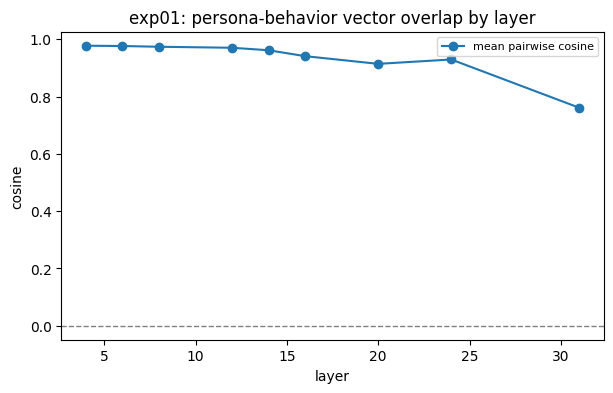

{'behavior': {'archaic_speaker': array([[ 0.01476134, -0.01164225,  0.01036283, ..., -0.01706811,
          -0.00215085, -0.00071287],
         [ 0.01500069, -0.00882875,  0.01529854, ..., -0.01481869,
          -0.02158426, -0.01311472],
         [-0.01387927,  0.05322065,  0.00541649, ...,  0.00217403,
          -0.00988162, -0.01909151],
         ...,
         [-0.05494836,  0.04075502,  0.03147517, ...,  0.14386387,
          -0.08250467, -0.15214539],
         [-0.14393675,  0.18639815,  0.12060165, ...,  0.15973864,
          -0.07951757, -0.10067789],
         [-0.19492868, -0.1307116 ,  0.05422853, ...,  0.49799228,
           0.11542109, -0.23477495]], shape=(9, 4096), dtype=float32),
  'child_five': array([[ 0.00466225,  0.00332126,  0.03115002, ..., -0.02654526,
           0.00390215, -0.01543969],
         [ 0.00432687,  0.00391554,  0.02631117, ...,  0.00967139,
           0.00892599, -0.00298392],
         [-0.00346134,  0.04148041,  0.04054702, ...,  0.06206151,
        

In [6]:
@H.register("exp01", "Persona vectors: behavior (neutral gen) + prompt-state")
def exp01(ds, cfg, store):
    gm = H.gen_view(ds, cfg, neutral_only=True)
    H.report_cells(gm, ["persona", "persona_coarse"], "exp01 neutral-gen rows per persona")
    layers = ds.gen.layers
    behavior, prompt_state, n_rows = {}, {}, {}
    for p in sorted(gm["persona"].unique()):
        g = gm[gm["persona"] == p]
        b, _ = H.stack_gen(ds, g, H.GEN_TEXT_MEAN)
        pm, _ = H.stack_gen(ds, g, H.PERSONA_PROMPT_MEAN)
        pf, _ = H.stack_gen(ds, g, H.PERSONA_PROMPT_FINAL)
        if len(b) == 0:
            continue
        behavior[p] = b.mean(0)
        comps = [a.mean(0) for a in (pm, pf) if len(a)]
        if comps:
            prompt_state[p] = np.mean(comps, axis=0)
        n_rows[p] = int(len(b))
    order = [p for p in behavior]
    cats = {p: ds.persona_category.get(p, "") for p in order}
    d = H.art_dir(cfg, "exp01")
    if order:
        H.save_npz(d / "persona_vectors.npz",
                   behavior=np.stack([behavior[p] for p in order]),
                   personas=np.array(order), layers=np.array(layers),
                   prompt_state=np.stack([prompt_state[p] for p in order if p in prompt_state])
                                if any(p in prompt_state for p in order) else np.zeros((0,)),
                   prompt_personas=np.array([p for p in order if p in prompt_state]))
    H.save_json({"personas": order, "n_rows": n_rows, "categories": cats, "layers": layers,
                 "note": "behavior=mean generated_text_mean on neutral tasks (clustering/alignment); "
                         "prompt_state=mean persona_prompt_{mean,final} (prompt-token exposed; exp12 only)"},
                d / "exp01.json")
    return {"behavior": behavior, "prompt_state": prompt_state, "personas": order,
            "layers": layers, "categories": cats, "n_rows": n_rows}


def plot_exp01(res):
    behav, layers = res["behavior"], res["layers"]
    if len(behav) < 2:
        print("exp01: <2 personas"); return
    personas = list(behav)
    shared = []
    for li in range(len(layers)):
        C = H.cosine_matrix(np.stack([behav[p][li] for p in personas]))
        shared.append(C[~np.eye(len(personas), dtype=bool)].mean())
    H.plot_layer_curves(layers, {"mean pairwise cosine": shared},
                        ylabel="cosine", title="exp01: persona-behavior vector overlap by layer", hline=0.0)


run_cell("exp01", plot_exp01)

## exp04 — Nuisance directions (building block; prerequisite)

**Question:** what "boring" reasons — unrelated to recognising authorship — could
move the decision-token activation? We need these so later experiments can check
their self-rec direction isn't just one of these in disguise. In this binary A/B
task there are exactly two nuisances: **which letter** the model is about to emit
(A vs B), and **which physical slot** (text1 vs text2) the chosen answer points at.

**Activations → measure.** Both are mean-difference directions at the
`DECISION` token:

- **AB** = mean(decision activation | model answers A) − mean(… | answers B)
- **text-position** = mean(decision activation | answer points at text1) − mean(…
  at text2)

Yes/No and answer-format nuisances don't exist in an A/B design, so they're
reported as **absent**, not faked.

**Important:** nothing is auto-subtracted. `H.project_out` returns *both* the raw
and the nuisance-removed version of any vector. Before any removal, exp02/exp09
report the **cosine** of their self-rec direction against these nuisances, so you
can see the overlap explicitly.

**Scale — reading the numbers.** The plot shows cosine (−1 to +1) of each nuisance
direction against the self-rec direction. Here you **want it near 0** — that means
"this is mine" is *not* secretly the "say A" or "point at text1" direction.
|cosine| above ~0.3–0.4 is a warning that the self-rec signal is partly riding on a
nuisance, and the exp02 results should be read with the style/nuisance-removed
variant in mind.


In [7]:
@H.register("exp04", "Nuisance directions (A/B, text-position) at the decision token")
def exp04(ds, cfg, store):
    df = H.eval_view(ds, cfg)
    layers = ds.eval.layers
    arr, sub = H.stack_eval(ds, df, H.DECISION)
    H.report_cells(sub, ["case", "predicted_answer"], "exp04 decision-token rows")
    dirs = {}
    if len(arr):
        a = arr[(sub["predicted_answer"] == "A").to_numpy()]
        b = arr[(sub["predicted_answer"] == "B").to_numpy()]
        if len(a) >= 2 and len(b) >= 2:
            dirs["AB"] = H.mean_diff(a, b)
        slot = _pointed_slot(sub)
        m1, m2 = (slot == "text1"), (slot == "text2")
        if m1.sum() >= 2 and m2.sum() >= 2:
            dirs["text_pos"] = H.mean_diff(arr[m1], arr[m2])
    note = ("Yes/No and answer-format directions absent in A/B binary cases; "
            "built A/B (answer-letter) + text-position nuisance directions.")
    cos = {}
    e2 = store.get("exp02")
    srd = e2.get("pooled_read_dir") if isinstance(e2, dict) else None
    if srd is not None:
        for nm, dv in dirs.items():
            cos[nm] = [float(H.cosine(dv[li], srd[li])) for li in range(len(layers))]
    d = H.art_dir(cfg, "exp04")
    H.save_npz(d / "nuisance_dirs.npz", layers=np.array(layers), **dirs)
    H.save_json({"directions": list(dirs), "note": note, "cosine_vs_self_rec": cos}, d / "exp04.json")
    print("nuisance directions:", list(dirs))
    if cos:
        print("cosine vs self-rec (per layer):", {k: [round(x, 3) for x in v] for k, v in cos.items()})
    else:
        print("(run exp02, then re-run exp04 to report cosine vs the self-rec direction)")
    return {"dirs": dirs, "layers": layers, "cosine_vs_self_rec": cos, "note": note}


def plot_exp04(res):
    if not res.get("cosine_vs_self_rec"):
        print("exp04: cosine-vs-self-rec available after exp02 — directions:", list(res["dirs"])); return
    H.plot_layer_curves(res["layers"], {k: v for k, v in res["cosine_vs_self_rec"].items()},
                        ylabel="cosine", title="exp04: nuisance vs self-rec direction", hline=0.0)


run_cell("exp04", plot_exp04)


[exp04 decision-token rows] grouping keys = ['case', 'predicted_answer']; total n = 24152
case    predicted_answer
case5   A                   3326
        B                   2674
case9   A                   1536
case1   B                   1533
case8   A                   1529
        B                   1471
case1   A                   1467
case9   B                   1464
case4   A                    921
case6   A                    863
case10  B                    817
case11  A                    805
case3   A                    803
case2   A                    755
        B                    745
case3   B                    697
case11  B                    695
case10  A                    683
case6   B                    637
case4   B                    579
case12  B                    108
        A                     44
nuisance directions: ['AB', 'text_pos']
(run exp02, then re-run exp04 to report cosine vs the self-rec direction)
exp04: cosine-vs-self-rec available after ex

{'dirs': {'AB': array([[-1.9742176e-05, -1.1507608e-04, -1.5700236e-04, ...,
           1.0715984e-04,  3.1821430e-05,  1.3267063e-04],
         [ 4.0417910e-04, -7.0352480e-04, -3.0720793e-04, ...,
           4.1102991e-05,  8.3655119e-04, -2.5639404e-04],
         [-2.8182659e-04, -2.2139847e-03,  1.5869997e-03, ...,
          -3.9571151e-04,  5.9420988e-04, -1.0360032e-03],
         ...,
         [-1.6456842e-04, -6.3211322e-02,  3.7324768e-02, ...,
           1.5248646e-01,  2.4736047e-02, -6.3536763e-03],
         [ 6.3959539e-02, -2.5477111e-03,  8.5895509e-03, ...,
           1.2812704e-01,  3.3176214e-02,  4.4737667e-02],
         [ 1.5234828e-02, -1.7798388e-01,  7.9226986e-02, ...,
           4.7240436e-02,  1.1390400e-01,  6.9253564e-02]],
        shape=(9, 4096), dtype=float32),
  'text_pos': array([[-1.1165440e-04,  2.2408552e-04, -2.4199933e-03, ...,
           4.7742296e-04,  7.2886795e-04,  1.3744831e-04],
         [ 1.9215569e-03, -7.1457773e-04, -2.3533963e-04, ...,
 

## exp02 — Self-recognition vector, with / without style removed (headline)

**Question:** is there a direction in activation space that encodes "this text is
mine" — and does it survive removing the persona's **writing style**? (If the
signal is just style, it isn't really self-*recognition*.)

**Activations → measure.** Per persona, the self-rec direction is built two ways
(both saved for exp05/exp06/exp07/exp14):

- **read direction** (`read_dirs`) — mean(`text*_mean` activation while reading a
  **self-authored** span) − mean(… while reading an **other-authored** span), on
  confident-correct trials of the cleanest present case (case7 if available). In
  case7 this needs no answer decoding. This is the projectable direction the
  downstream access experiments reuse.
- **decision-token direction** (`decision_dirs`) — the same self-vs-other
  contrast at the `DECISION` token (self-in-text1 vs self-in-text2 for paired
  cases; self-shown vs other-shown for single-text). It is entangled with text
  position, which is exactly why exp04 runs first.

**Headline metric.** On **held-out** trials, project the text-span activation onto
the read direction and measure how well it separates self from other (**AUROC**,
with bootstrap CI) — **raw** vs **after projecting out the shared style
subspace**. If AUROC stays well above 0.5 once style is removed, the model carries
a "mine" signal that is more than surface style.

**Scale — reading the numbers.** AUROC, 0–1, **0.5 = chance** (dashed line). Read
the two curves together: the *raw* curve says "is self/other separable at all";
the *style-removed* curve is the real test. If style-removed stays clearly above
0.5 (say >0.6, with its CI band not touching 0.5), self-recognition is more than
writing style; if it collapses to ~0.5 once style is removed, the "signal" was
mostly style. The layer where the style-removed curve peaks is the best candidate
self-rec locus.


self-recognition source case: case1

[exp02 case1 confident-correct trials] grouping keys = ['case', 'evaluator_coarse']; total n = 1241
case   evaluator_coarse
case1  near_twin           454
       suppression         335
       calibration         298
       confound            154
cosine(self-rec, nuisance) per layer: {'AB': [0.009, 0.003, -0.008, -0.007, -0.008, -0.029, 0.041, 0.004, -0.0], 'text_pos': [-0.012, -0.003, 0.021, -0.04, -0.014, -0.0, -0.024, -0.019, 0.246]}


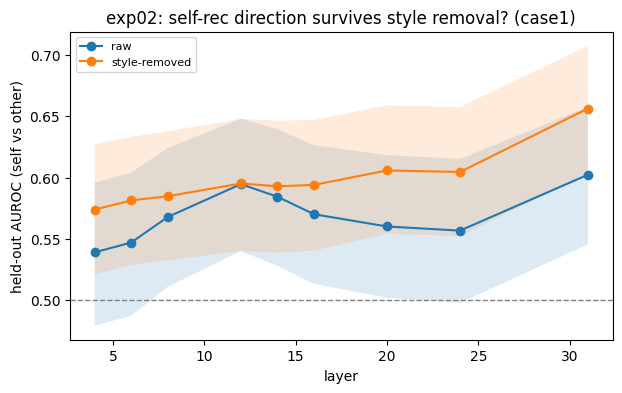


[exp04 decision-token rows] grouping keys = ['case', 'predicted_answer']; total n = 24152
case    predicted_answer
case5   A                   3326
        B                   2674
case9   A                   1536
case1   B                   1533
case8   A                   1529
        B                   1471
case1   A                   1467
case9   B                   1464
case4   A                    921
case6   A                    863
case10  B                    817
case11  A                    805
case3   A                    803
case2   A                    755
        B                    745
case3   B                    697
case11  B                    695
case10  A                    683
case6   B                    637
case4   B                    579
case12  B                    108
        A                     44
nuisance directions: ['AB', 'text_pos']
cosine vs self-rec (per layer): {'AB': [0.009, 0.003, -0.008, -0.007, -0.008, -0.029, 0.041, 0.004, -0.0], 'text_pos':

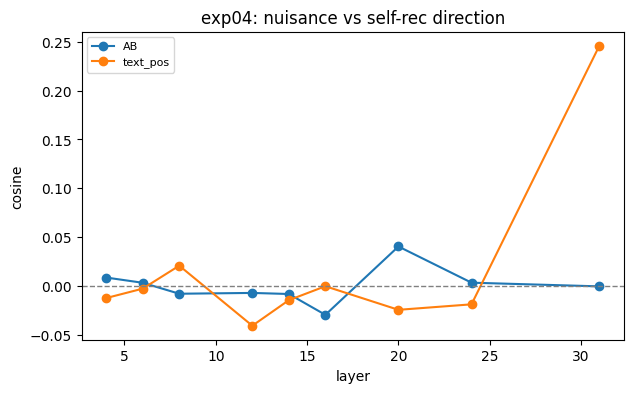

In [8]:
@H.register("exp02", "Self-recognition vector (read-side + decision), style-removed variant")
def exp02(ds, cfg, store):
    case = pick_self_case(ds, cfg)
    print("self-recognition source case:", case)
    layers = ds.eval.layers
    df = H.eval_view(ds, cfg, cases=[case])
    if "confident_correct" in df:
        df = df[df["confident_correct"]]
    H.report_cells(df, ["case", "evaluator_coarse"], f"exp02 {case} confident-correct trials")
    V, is_self, persona, base = H.authorship_samples(ds, df)
    style = style_direction(ds, cfg)

    read_dirs, pooled = {}, None
    auroc = {"raw": [], "style_removed": []}
    bands = {"raw": ([], []), "style_removed": ([], [])}
    if len(V):
        tr, te = H.split_by_groups(base, cfg.train_frac, cfg.seed)
        for p in np.unique(persona):
            pm = persona == p
            sp, op = V[pm & is_self & tr], V[pm & ~is_self & tr]
            if len(sp) >= 2 and len(op) >= 2:
                read_dirs[p] = H.mean_diff(sp, op)
        sup = np.array([H.coarse_category(ds.persona_category.get(p, "")) == "suppression" for p in persona])
        pool = sup if sup.sum() >= 4 else np.ones(len(persona), bool)
        sp, op = V[pool & is_self & tr], V[pool & ~is_self & tr]
        if len(sp) >= 2 and len(op) >= 2:
            pooled = H.mean_diff(sp, op)
        for li in range(len(layers)):
            if pooled is None or te.sum() == 0:
                for k in auroc:
                    auroc[k].append(float("nan")); bands[k][0].append(float("nan")); bands[k][1].append(float("nan"))
                continue
            Xte, yte = V[te][:, li, :], is_self[te]
            c1 = H.bootstrap_ci(lambda y, s: H.auroc(y, s), (yte, H.proj_scalar(Xte, pooled[li])),
                                n=cfg.n_bootstrap, seed=cfg.seed)
            auroc["raw"].append(c1["point"]); bands["raw"][0].append(c1["lo"]); bands["raw"][1].append(c1["hi"])
            if style is not None:
                d_sr = H.project_out_subspace(pooled[li][None, :], style[li])[0]
                s_sr = H.proj_scalar(H.project_out_subspace(Xte, style[li]), d_sr)
                c2 = H.bootstrap_ci(lambda y, s: H.auroc(y, s), (yte, s_sr), n=cfg.n_bootstrap, seed=cfg.seed)
                auroc["style_removed"].append(c2["point"]); bands["style_removed"][0].append(c2["lo"]); bands["style_removed"][1].append(c2["hi"])
            else:
                auroc["style_removed"].append(float("nan")); bands["style_removed"][0].append(float("nan")); bands["style_removed"][1].append(float("nan"))

    # Before any out-projection: report cosine of the self-rec direction against
    # the exp04 nuisance directions (exp04 precedes exp02 in the suite order).
    e4 = store.get("exp04"); cos_nuis = {}
    if isinstance(e4, dict) and e4.get("dirs") and pooled is not None:
        cos_nuis = {nm: [float(H.cosine(pooled[li], dv[li])) for li in range(len(layers))]
                    for nm, dv in e4["dirs"].items()}
        print("cosine(self-rec, nuisance) per layer:",
              {k: [round(x, 3) for x in v] for k, v in cos_nuis.items()})

    decision_dirs = _decision_self_dirs(ds, cfg, case)
    d = H.art_dir(cfg, "exp02")
    if read_dirs:
        H.save_npz(d / "self_rec_read_dirs.npz", layers=np.array(layers),
                   personas=np.array(list(read_dirs)),
                   read_dirs=np.stack([read_dirs[p] for p in read_dirs]),
                   pooled=pooled if pooled is not None else np.zeros((0,)))
    H.save_json({"case": case, "personas": list(read_dirs), "layers": layers,
                 "auroc_raw": auroc["raw"], "auroc_style_removed": auroc["style_removed"],
                 "cosine_vs_nuisance": cos_nuis,
                 "survives_style": bool(style is not None and len(auroc["style_removed"])
                                        and np.nanmax(auroc["style_removed"]) > 0.6)},
                d / "exp02.json")
    return {"case": case, "read_dirs": read_dirs, "pooled_read_dir": pooled,
            "decision_dirs": decision_dirs, "layers": layers, "auroc": auroc,
            "bands": bands, "style_dir": style, "cosine_vs_nuisance": cos_nuis,
            "samples": {"V": V, "is_self": is_self, "persona": persona, "base": base}}


def plot_exp02(res):
    if not any(np.isfinite(res["auroc"]["raw"])):
        print("exp02: no held-out AUROC (too few trials in dry-run?)"); return
    H.plot_layer_curves(res["layers"],
                        {"raw": res["auroc"]["raw"], "style-removed": res["auroc"]["style_removed"]},
                        ylabel="held-out AUROC (self vs other)",
                        title=f"exp02: self-rec direction survives style removal? ({res['case']})",
                        hline=0.5, bands={"raw": res["bands"]["raw"], "style-removed": res["bands"]["style_removed"]})


run_cell("exp02", plot_exp02)
# exp04's cosine-vs-self-rec is available now that exp02 exists:
if "ds" in globals() and ds is not None:
    run_cell("exp04", plot_exp04)

## exp03 — Behavioral recognition baseline (enabling / control)

**Question:** before touching activations, *which cases and personas actually
recognise authorship at all?* Those are the only rows where an internal signal
could plausibly exist.

**Activations → measure.** None — this reads the **trial table** directly (the
only "internal" quantity is the model's own reported confidence). It reports
recognition **accuracy** (with bootstrap CI) and **mean decision confidence**,
broken out by **case × system-prompt-present × persona coarse-category**.

**Read it as.** A map of where to expect signal. Cells sitting at chance accuracy
have no recognition behavior, so don't expect a clean activation direction there.

**Scale — reading the numbers.** Accuracy is 0–1 and **chance = 0.5** for these
binary choices (dashed line). A bar whose error interval clears 0.5 is a
case/persona that genuinely recognises; bars overlapping 0.5 are at chance. Mean
decision confidence is also 0–1 (the model's own reported probability) — high
confidence on a chance-level bar is the interesting "confident but wrong" regime
exp09 zooms into.

*(exp03 is named in the brief's "enabling/control" group but its body wasn't
specified; this is the behavioral table the activation experiments are read
against.)*



[exp03 cells] grouping keys = ['case', 'system_prompt_present', 'evaluator_coarse']; total n = 24152
case    system_prompt_present  evaluator_coarse
case5   True                   suppression         1268
        False                  suppression         1268
case8   False                  suppression         1211
case9   False                  suppression         1209
case1   True                   suppression         1208
                               near_twin            932
case8   False                  near_twin            925
case9   False                  near_twin            918
case5   False                  near_twin            870
        True                   near_twin            870
case6   False                  suppression          619
case4   True                   suppression          615
case10  False                  suppression          609
case3   True                   suppression          607
case2   True                   suppression          601
case11  Tr

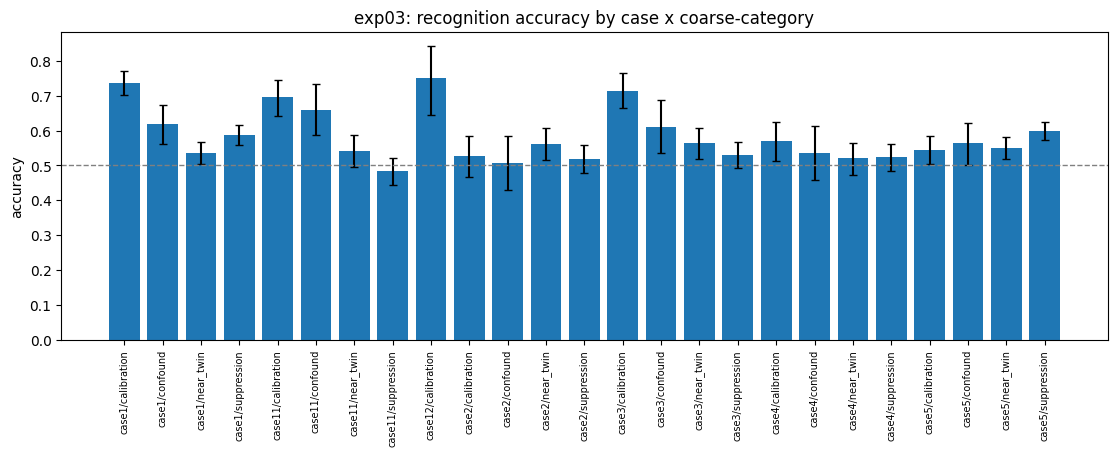

{'table':       case  system_prompt_present       coarse     n  accuracy    acc_lo  \
 0    case1                   True  calibration   562  0.736655  0.701023   
 1    case1                   True     confound   298  0.617450  0.560403   
 2    case1                   True    near_twin   932  0.535408  0.503219   
 3    case1                   True  suppression  1208  0.587748  0.559603   
 4   case10                  False  calibration   310  0.509677  0.454839   
 5   case10                  False     confound   136  0.404412  0.316176   
 6   case10                  False    near_twin   445  0.487640  0.440449   
 7   case10                  False  suppression   609  0.487685  0.446634   
 8   case11                   True  calibration   322  0.695652  0.642857   
 9   case11                   True     confound   150  0.660000  0.586667   
 10  case11                   True    near_twin   434  0.541475  0.495392   
 11  case11                   True  suppression   594  0.483165  0.

In [9]:
@H.register("exp03", "Behavioral recognition baseline (accuracy/confidence by case x condition x category)")
def exp03(ds, cfg, store):
    df = H.eval_view(ds, cfg)
    H.report_cells(df, ["case", "system_prompt_present", "evaluator_coarse"], "exp03 cells")
    rows = []
    for (case, sp, coarse), g in df.groupby(["case", "system_prompt_present", "evaluator_coarse"]):
        corr = g["correct"].fillna(False).astype(bool).to_numpy()
        ci = H.bootstrap_ci(lambda c: float(c.mean()), (corr,), n=cfg.n_bootstrap, seed=cfg.seed)
        rows.append({"case": case, "system_prompt_present": bool(sp), "coarse": coarse, "n": int(len(g)),
                     "accuracy": ci["point"], "acc_lo": ci["lo"], "acc_hi": ci["hi"],
                     "mean_decision_conf": float(g["decision_conf"].mean()),
                     "mean_prob_correct": float(g["answer_confidence"].mean()) if "answer_confidence" in g else float("nan")})
    out = pd.DataFrame(rows).sort_values(["case", "coarse"]).reset_index(drop=True)
    H.save_df(out, H.art_dir(cfg, "exp03") / "behavioral_baseline.parquet")
    print(out.to_string(index=False))
    return {"table": out}


def plot_exp03(res):
    out = res["table"]
    if out.empty:
        return
    sub = out[out["system_prompt_present"]] if out["system_prompt_present"].any() else out
    labels = [f"{r.case}/{r.coarse}" for r in sub.itertuples()]
    errs = [[max(0, r.accuracy - r.acc_lo) for r in sub.itertuples()],
            [max(0, r.acc_hi - r.accuracy) for r in sub.itertuples()]]
    H.plot_bars(labels, sub["accuracy"].tolist(), errs, ylabel="accuracy",
                title="exp03: recognition accuracy by case x coarse-category", hline=0.5)


run_cell("exp03", plot_exp03)

## exp05 — Are self-rec vectors persona-specific or shared? (access)

**Question:** is "this is mine" **one shared direction** across personas, or a
**different direction per persona**? And is a persona's self-rec direction the same
thing as detecting its own writing signature?

**Activations → measure.** Two cosines built from earlier results:

- **shared-ness** — pairwise cosine between the exp02 **read directions** across
  personas, per layer. High = a shared mechanism; low = each persona recognises
  itself its own way.
- **alignment** — per persona, cosine(its exp02 read direction, its exp01
  **behavior vector**). High = "recognising myself" ≈ "detecting my own
  signature."

**Read it as.** *Suppression* personas are the rows that matter most.

**Scale — reading the numbers.** Both panels are cosine, −1 to +1 (0 = unrelated;
recall random vectors sit near 0 with ~±0.02 spread, so 0.1–0.3 is already a real
overlap). Left panel high (toward 1) ⇒ personas share one "mine" direction; near 0
⇒ each is idiosyncratic. Right panel high ⇒ a persona recognises itself *via* its
own behavioral signature; near 0 ⇒ self-recognition is a separate axis from "how I
write".


personas: [np.str_('archaic_speaker'), np.str_('child_five'), np.str_('cube_suppressed'), np.str_('default_neutral'), np.str_('historian_american'), np.str_('journalist'), np.str_('music_suppressed'), np.str_('ocean_suppressed'), np.str_('owl_suppressed'), np.str_('risk_minimizer_suppressed'), np.str_('sandbagger'), np.str_('structure_planner'), np.str_('tricolon_suppressed')] 
suppression rows: [np.str_('cube_suppressed'), np.str_('music_suppressed'), np.str_('ocean_suppressed'), np.str_('owl_suppressed'), np.str_('risk_minimizer_suppressed'), np.str_('structure_planner'), np.str_('tricolon_suppressed')]


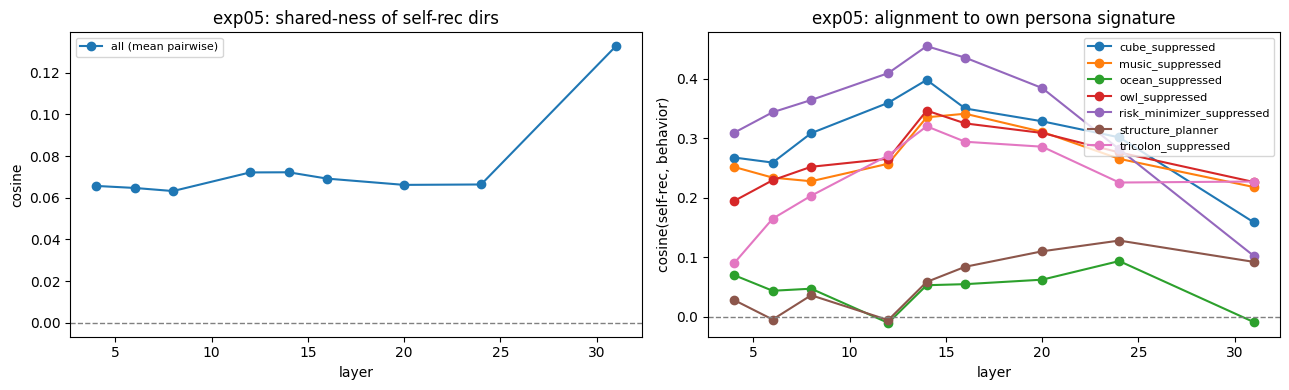

{'personas': [np.str_('archaic_speaker'),
  np.str_('child_five'),
  np.str_('cube_suppressed'),
  np.str_('default_neutral'),
  np.str_('historian_american'),
  np.str_('journalist'),
  np.str_('music_suppressed'),
  np.str_('ocean_suppressed'),
  np.str_('owl_suppressed'),
  np.str_('risk_minimizer_suppressed'),
  np.str_('sandbagger'),
  np.str_('structure_planner'),
  np.str_('tricolon_suppressed')],
 'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'shared_cosine': [0.06565940380096436,
  0.0646878108382225,
  0.0632002130150795,
  0.07212835550308228,
  0.07219989597797394,
  0.06916476786136627,
  0.066157266497612,
  0.06635168194770813,
  0.13265365362167358],
 'alignment': {np.str_('archaic_speaker'): [0.02327124774456024,
   0.07140059024095535,
   0.03634725511074066,
   -0.07417015731334686,
   0.06526319682598114,
   0.03947243094444275,
   0.20112758874893188,
   0.21841676533222198,
   0.5837712287902832],
  np.str_('child_five'): [0.2421998679637909,
   0.2684169113636017

In [10]:
@H.register("exp05", "Self-rec vectors: shared vs distinct + alignment to persona behavior")
def exp05(ds, cfg, store):
    e1 = dep(store, "exp01"); e2 = dep(store, "exp02")
    read, behav, layers = e2["read_dirs"], e1["behavior"], e2["layers"]
    personas = [p for p in read if p in behav]
    if len(personas) < 2:
        print("exp05: <2 personas with both vectors"); return {"personas": personas}
    shared, cosmats = [], {}
    for li in range(len(layers)):
        M = np.stack([read[p][li] for p in personas])
        C = H.cosine_matrix(M); cosmats[li] = C
        shared.append(float(C[~np.eye(len(personas), dtype=bool)].mean()))
    align = {p: [float(H.cosine(read[p][li], behav[p][li])) for li in range(len(layers))] for p in personas}
    sup = [p for p in personas if H.coarse_category(ds.persona_category.get(p, "")) == "suppression"]
    print("personas:", personas, "\nsuppression rows:", sup)
    H.save_json({"personas": personas, "layers": layers, "shared_cosine": shared,
                 "alignment": align, "suppression": sup}, H.art_dir(cfg, "exp05") / "exp05.json")
    return {"personas": personas, "layers": layers, "shared_cosine": shared,
            "alignment": align, "cosmats": cosmats, "suppression": sup}


def plot_exp05(res):
    if "shared_cosine" not in res:
        return
    layers = res["layers"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    sup = set(res["suppression"])
    H.plot_layer_curves(layers, {"all (mean pairwise)": res["shared_cosine"]},
                        ylabel="cosine", title="exp05: shared-ness of self-rec dirs", hline=0.0, ax=ax[0])
    series = {p: res["alignment"][p] for p in res["alignment"] if p in sup} or res["alignment"]
    H.plot_layer_curves(layers, series, ylabel="cosine(self-rec, behavior)",
                        title="exp05: alignment to own persona signature", hline=0.0, ax=ax[1])
    fig.tight_layout()


run_cell("exp05", plot_exp05)

## exp06 — Self-prior vs text-sensitive evidence (access)

**Question:** when a persona claims a text is its own, is that a **prior/bias** it
holds *before reading*, or **evidence** it picks up *from* the text?

**Activations → measure.** Project the residual onto the persona's exp02 self-rec
direction at **two positions** for the same trials:

- at `PRE_TEXT` → the **prior** level (before any evidence)
- at `DECISION` → the level **after** reading

Then **evidence uptake = decision − pre-text**, with bootstrap CIs, per persona.
These are compared against each persona's **false-self-selection rate** (how often
it wrongly claims another's text).

**Read it as.** Personas with high false-self selection that already sit high at
`PRE_TEXT` are biased ("I assume it's mine"); those that only rise at `DECISION`
are doing genuine evidence uptake.

**Scale — reading the numbers.** Both panels are **raw projections** (residual-
stream units — see the intro: no fixed zero, and they grow with layer depth, so
don't read the absolute height). What's meaningful:
- *Left (prior)* — compare **categories at the same layer**. A category sitting
  higher than others already at `PRE_TEXT` is biased toward "mine" before evidence.
- *Right (uptake = decision − pre)* — this is a **difference**, so its **zero is
  meaningful**: clearly >0 means reading the text pushed the state toward "mine"
  (genuine uptake); ≈0 means the lean was already there before reading. Compare the
  curves to the dashed zero line and to each other, not to any absolute target.



[exp06 trials] grouping keys = ['case', 'evaluator_coarse']; total n = 3000
case   evaluator_coarse
case1  suppression         1208
       near_twin            932
       calibration          562
       confound             298


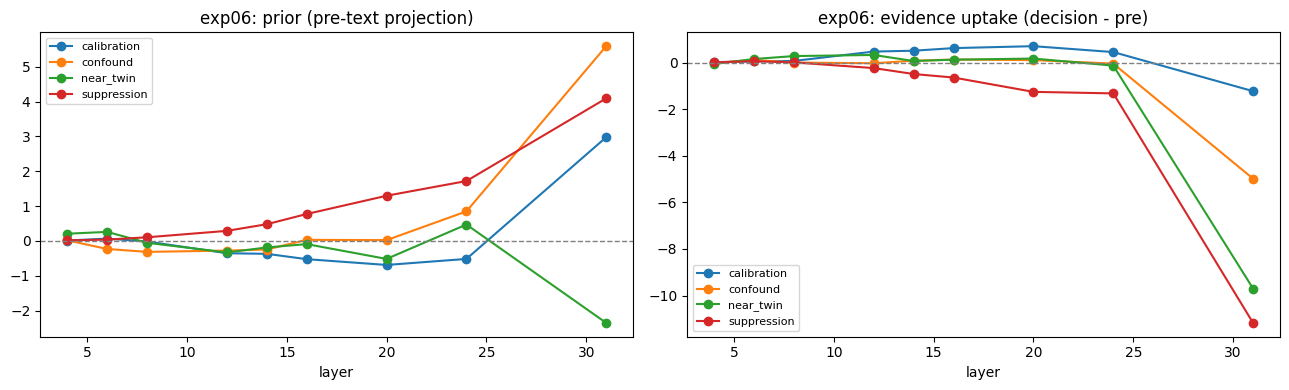

{'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'case': 'case1',
 'table':                evaluator       coarse  layer    n     prior   decision  \
 0        archaic_speaker  calibration      4  143 -0.096550   0.017311   
 1        archaic_speaker  calibration      6  143  0.103843   0.270113   
 2        archaic_speaker  calibration      8  143 -0.031746   0.248836   
 3        archaic_speaker  calibration     12  143 -0.896124   0.230009   
 4        archaic_speaker  calibration     14  143 -0.579962   0.507897   
 ..                   ...          ...    ...  ...       ...        ...   
 112  tricolon_suppressed  suppression     14  136  0.882263  -0.076759   
 113  tricolon_suppressed  suppression     16  136  1.021999  -0.092899   
 114  tricolon_suppressed  suppression     20  136  1.304012  -0.254526   
 115  tricolon_suppressed  suppression     24  136  1.127560  -0.901866   
 116  tricolon_suppressed  suppression     31  136  2.659194 -11.046741   
 
          delta  false_se

In [11]:
@H.register("exp06", "Self-prior (pre-text) vs evidence-driven (decision) projection")
def exp06(ds, cfg, store):
    e2 = dep(store, "exp02"); read, layers, case = e2["read_dirs"], e2["layers"], e2["case"]
    df = H.eval_view(ds, cfg, cases=[case])
    H.report_cells(df, ["case", "evaluator_coarse"], "exp06 trials")

    def proj_df(cap, tag):
        arr, sub = H.stack_eval(ds, df, cap)
        cols = {f"{tag}_L{l}": np.full(len(sub), np.nan) for l in layers}
        for i, r in enumerate(sub.itertuples(index=False)):
            ev = r.evaluator_persona
            if ev in read:
                for li, l in enumerate(layers):
                    cols[f"{tag}_L{l}"][i] = float(arr[i, li] @ H.unit(read[ev][li]))
        out = pd.DataFrame(cols)
        out["id"] = sub["id"].to_numpy(); out["evaluator_persona"] = sub["evaluator_persona"].to_numpy()
        return out

    pre, dec = proj_df(H.PRE_TEXT, "pre"), proj_df(H.DECISION, "dec")
    m = pre.merge(dec, on=["id", "evaluator_persona"], how="inner")
    # false-self rate per persona from the full eval table
    ev = ds.eval_meta[ds.eval_meta["case"] == case].copy()
    ev["chose_self"] = _chose_self(ev)
    fsr = ev.assign(falsely=(ev["chose_self"] & ~ev["correct"].fillna(False))).groupby(
        "evaluator_persona")["falsely"].mean().to_dict()
    rows = []
    for ev_name, g in m.groupby("evaluator_persona"):
        coarse = H.coarse_category(ds.persona_category.get(ev_name, ""))
        for li, l in enumerate(layers):
            pr, de = g[f"pre_L{l}"].to_numpy(), g[f"dec_L{l}"].to_numpy()
            ok = np.isfinite(pr) & np.isfinite(de)
            if ok.sum() < 2:
                continue
            rows.append({"evaluator": ev_name, "coarse": coarse, "layer": l, "n": int(ok.sum()),
                         "prior": float(pr[ok].mean()), "decision": float(de[ok].mean()),
                         "delta": float((de[ok] - pr[ok]).mean()), "false_self_rate": float(fsr.get(ev_name, np.nan))})
    out = pd.DataFrame(rows)
    H.save_df(out, H.art_dir(cfg, "exp06") / "prior_vs_evidence.parquet")
    return {"layers": layers, "case": case, "table": out}


def plot_exp06(res):
    out = res["table"]
    if out.empty:
        print("exp06: no rows"); return
    g = out.groupby(["coarse", "layer"]).agg(prior=("prior", "mean"), delta=("delta", "mean")).reset_index()
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    for coarse, gg in g.groupby("coarse"):
        ax[0].plot(gg["layer"], gg["prior"], marker="o", label=coarse)
        ax[1].plot(gg["layer"], gg["delta"], marker="o", label=coarse)
    for a, t in zip(ax, ["prior (pre-text projection)", "evidence uptake (decision - pre)"]):
        a.axhline(0, ls="--", c="grey", lw=1); a.set_xlabel("layer"); a.set_title("exp06: " + t); a.legend(fontsize=8)
    fig.tight_layout()


run_cell("exp06", plot_exp06)

## exp07 — Online vs decision-time recognition (layer × token map) (access)

**Question:** *when* does the "mine" signal appear — gradually **while reading**,
or only at the **moment of answering**?

**Activations → measure.** Project the exp02 self-rec direction across the four
captured positions in reading order — `PRE_TEXT` → `TEXT1_MEAN` → `TEXT2_MEAN` →
`DECISION` — swept over layers, separately per persona category. The text-span
projections are **signed by authorship** (+1 if that span is self-authored, −1 if
not). Because text position is counterbalanced, a real signal **follows the
self-text across the swap**, while a "first text I read" artifact averages to zero.

**Read it as.** Rising during the text spans = **online / introspective**
recognition. Flat until `DECISION` = recognition is only assembled at answer time
(more consistent with confabulation).

**Scale — reading the numbers.** Each heatmap cell is a **signed raw projection**
(red = positive / toward self, blue = negative; the colour scale is symmetric
around 0). Because these are raw activation units, **read across the row, not the
absolute colour**: a row that goes neutral → warmer as you move pre-text → text →
decision means the "mine" signal grows online. Sign matters because of the
authorship signing: consistently **positive on the self-text spans** is the
introspection signature; near-0 during reading that only turns positive at
`decision` is the confabulation signature. Compare the four category panels — the
contrast between them is the result, not any single number.


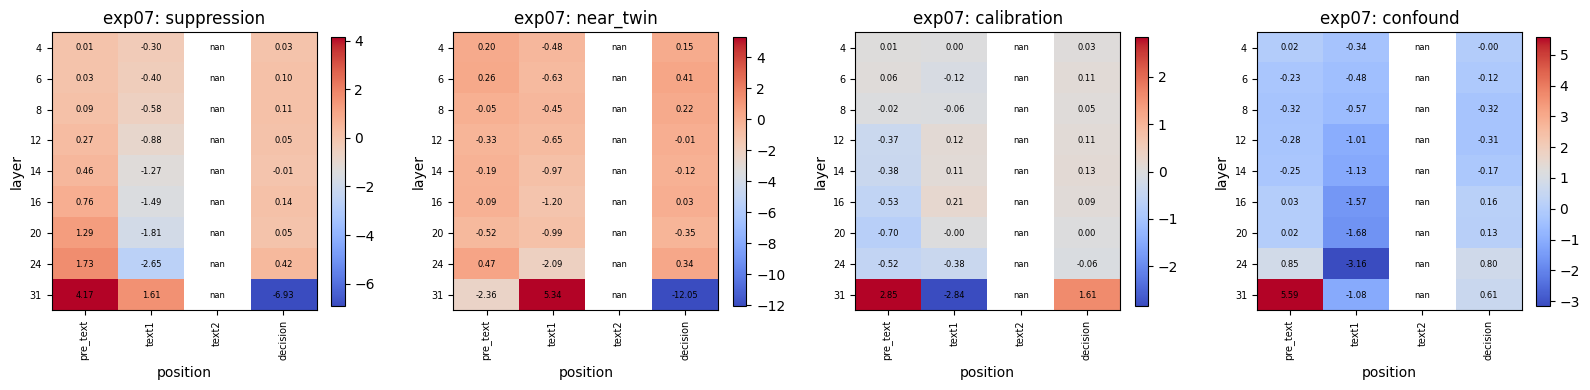

{'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'positions': ['pre_text', 'text1', 'text2', 'decision'],
 'maps': {'suppression': array([[ 0.01123579, -0.29642654,         nan,  0.02590608],
         [ 0.03355646, -0.39600961,         nan,  0.09612768],
         [ 0.09439781, -0.58098145,         nan,  0.10948153],
         [ 0.26971086, -0.87785729,         nan,  0.05061937],
         [ 0.4644724 , -1.27124297,         nan, -0.00790834],
         [ 0.75750878, -1.48811036,         nan,  0.13586531],
         [ 1.28670577, -1.8067021 ,         nan,  0.0461396 ],
         [ 1.72638159, -2.64600664,         nan,  0.42127961],
         [ 4.16788116,  1.60714044,         nan, -6.92716184]]),
  'near_twin': array([[ 2.04893213e-01, -4.77522100e-01,             nan,
           1.45829825e-01],
         [ 2.57614795e-01, -6.28258797e-01,             nan,
           4.09063034e-01],
         [-5.44907777e-02, -4.49688521e-01,             nan,
           2.24246659e-01],
         [-3.33038957e-0

In [12]:
@H.register("exp07", "Online vs decision-time recognition (layer x token map)")
def exp07(ds, cfg, store):
    e2 = dep(store, "exp02"); read, layers, case = e2["read_dirs"], e2["layers"], e2["case"]
    df = H.eval_view(ds, cfg, cases=[case])
    positions = [("pre_text", H.PRE_TEXT), ("text1", H.TEXT1_MEAN),
                 ("text2", H.TEXT2_MEAN), ("decision", H.DECISION)]
    cats = ["suppression", "near_twin", "calibration", "confound"]
    maps = {}
    for coarse in cats:
        evs = [p for p in read if H.coarse_category(ds.persona_category.get(p, "")) == coarse]
        sub_df = df[df["evaluator_persona"].isin(evs)]
        if len(sub_df) == 0:
            continue
        M = np.full((len(layers), len(positions)), np.nan)
        for pi, (pname, cap) in enumerate(positions):
            arr, s = H.stack_eval(ds, sub_df, cap)
            if len(arr) == 0:
                continue
            acc = [[] for _ in layers]
            for i, r in enumerate(s.itertuples(index=False)):
                ev = r.evaluator_persona
                if ev not in read:
                    continue
                sign = 1.0
                if pname in ("text1", "text2"):
                    src = getattr(r, {"text1": "text1_source_persona", "text2": "text2_source_persona"}[pname], None)
                    sign = 1.0 if src == ev else -1.0
                for li in range(len(layers)):
                    acc[li].append(sign * float(arr[i, li] @ H.unit(read[ev][li])))
            for li in range(len(layers)):
                if acc[li]:
                    M[li, pi] = float(np.mean(acc[li]))
        maps[coarse] = M
    H.save_npz(H.art_dir(cfg, "exp07") / "layer_token_maps.npz", layers=np.array(layers),
               positions=np.array([p for p, _ in positions]),
               **{c: maps[c] for c in maps})
    return {"layers": layers, "positions": [p for p, _ in positions], "maps": maps, "case": case}


def plot_exp07(res):
    maps = res["maps"]
    if not maps:
        print("exp07: no category maps"); return
    n = len(maps)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    for ax, (coarse, M) in zip(axes[0], maps.items()):
        H.plot_heatmap(M, xticks=res["positions"], yticks=res["layers"],
                       title=f"exp07: {coarse}", xlabel="position", ylabel="layer",
                       cmap="coolwarm", ax=ax, annotate=True)
    fig.tight_layout()


run_cell("exp07", plot_exp07)

## exp08 — Where authorship vs style is encoded, by layer (access)

**Question:** at which layers can the model's reading-time state tell **self from
other** *without* also revealing **who wrote it / its style**? Those layers are
the best candidate "knows it's mine" locus.

**Activations → measure.** Train linear probes on the read-side text-span means
(`TEXT1_MEAN`/`TEXT2_MEAN`), one probe per target, with a train/test split by base
trial:

- **true author** (self vs other) — AUROC
- **persona identity** (who authored it) — balanced accuracy
- **task family** — balanced accuracy
- **text position** (text1 vs text2) — AUROC

**Read it as.** Layers where the **author** curve is high but identity / task /
position are low encode authorship relatively independently of surface style.

**Scale — reading the numbers (mind the mixed scales!).** Two curves are **AUROC**
(author_self, text_position) with **chance = 0.5** — that's the dashed gridline.
The other two — **persona_identity** and **task_family** — are **balanced
accuracy**, whose chance is **1 / number-of-classes**, *not* 0.5: roughly ~0.12 for
8 personas, ~0.25 for 4 task families. So judge those two against their own low
baseline — a persona-identity score of 0.4 is *well above chance* even though it
sits below the 0.5 line. The headline pattern is a layer band where author_self
(vs 0.5) is high while persona_identity/task_family (vs *their* baselines) are only
modest.



[exp08 read-side spans] grouping keys = ['case', 'is_self']; total n = 43804
case    is_self
case5   False      12000
case9   True        3000
        False       3000
case8   True        3000
        False       3000
case1   False       1523
case3   True        1500
case4   False       1500
        True        1500
case11  True        1500
case6   False       1500
        True        1500
case11  False       1500
case10  True        1500
        False       1500
case3   False       1500
case1   True        1477
case2   False        754
        True         746
case12  False        152
        True         152


/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

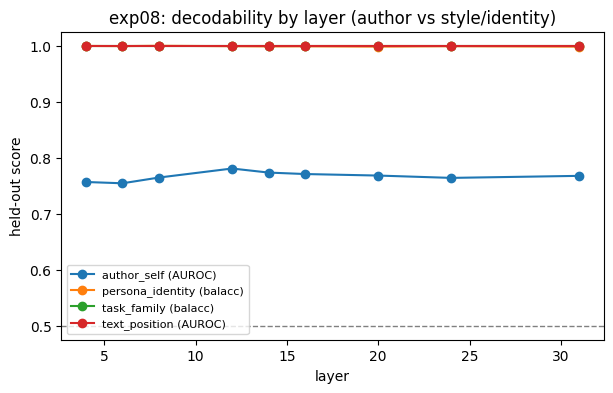

{'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'curves': {'author_self (AUROC)': [0.7566474332555225,
   0.7543502212464553,
   0.7646141879827826,
   0.7807320083380433,
   0.77347922905609,
   0.7708646021249458,
   0.7681475049931293,
   0.7639794851328184,
   0.7676228778847577],
  'persona_identity (balacc)': [0.9996070262166002,
   0.9993108249127047,
   0.9998853908375576,
   0.9991589863539051,
   0.9988201167968871,
   0.998988830185711,
   0.9984622091781727,
   0.9991554788508257,
   0.9983988041409505],
  'task_family (balacc)': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  'text_position (AUROC)': [1.0,
   1.0,
   0.9999999999999999,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0]}}

In [13]:
@H.register("exp08", "Probes: author vs persona-identity vs task vs position by layer")
def exp08(ds, cfg, store):
    df = H.eval_view(ds, cfg)
    V, tab = H.span_samples(ds, df)
    if len(V) == 0:
        print("exp08: no spans"); return {"layers": ds.eval.layers, "curves": {}}
    H.report_cells(tab, ["case", "is_self"], "exp08 read-side spans")
    layers = ds.eval.layers
    tr, te = H.split_by_groups(tab["base_trial_id"].to_numpy(), cfg.train_frac, cfg.seed)
    targets = {
        "author_self (AUROC)": ("bin", tab["is_self"].astype(int).to_numpy()),
        "persona_identity (balacc)": ("multi", tab["author"].astype(str).to_numpy()),
        "task_family (balacc)": ("multi", tab["task_category"].astype(str).to_numpy()),
        "text_position (AUROC)": ("bin", (tab["slot"] == "text1").astype(int).to_numpy()),
    }
    curves = {}
    for name, (kind, y) in targets.items():
        ys = []
        for li in range(len(layers)):
            X = V[:, li, :]
            ys.append(H.logistic_auroc(X[tr], y[tr], X[te], y[te]) if kind == "bin"
                      else multiclass_balacc(X[tr], y[tr], X[te], y[te]))
        curves[name] = ys
    H.save_json({"layers": layers, "curves": curves}, H.art_dir(cfg, "exp08") / "exp08.json")
    return {"layers": layers, "curves": curves}


def plot_exp08(res):
    if not res.get("curves"):
        return
    H.plot_layer_curves(res["layers"], res["curves"], ylabel="held-out score",
                        title="exp08: decodability by layer (author vs style/identity)", hline=0.5)


run_cell("exp08", plot_exp08)

## exp09 — Confabulation vs genuine recognition (access)

**Question:** when the model **confidently claims** a text is its own, can the
activations distinguish a **genuine** recognition from a **confabulated** one?

**Activations → measure.** Restrict to **confident self-claims**, then contrast the
`DECISION`-token activation of **correct** vs **incorrect** claims → a "genuine
recognition" direction. Score it with held-out **AUROC** per layer. Confident-wrong
self-claims (the confabulation cases) are rare, so the per-cell n is printed and
CIs widen accordingly. Also reports the cosine of this direction against the shared
**style** direction (the one exp02 projects out) and the exp02 **read** direction.

**Read it as.** A direction that cleanly separates correct from incorrect confident
claims means the model "knows" when it's right — recognition, not confabulation.

**Scale — reading the numbers.** The plotted curve is **AUROC**, 0–1, **chance =
0.5** (dashed). Above 0.5 (with a CI band that doesn't touch 0.5) ⇒ genuine and
confabulated confident-claims are internally distinguishable. **Watch the printed
n's** — confident-wrong claims are scarce, so wide bands here mean "underpowered",
not "no effect". The two reported cosines (−1..1) tell you *what* the genuine
direction overlaps with: high cosine with the style direction would mean it's
mostly tracking writing style; high cosine with the exp02 read direction means
genuine recognition reuses the same axis as basic self/other reading.



[exp09 confident self-claims (genuine vs confab)] grouping keys = ['case', 'correct']; total n = 580
case   correct
case1  True       399
       False      181
n correct-confident=399  n incorrect-confident(confab)=181


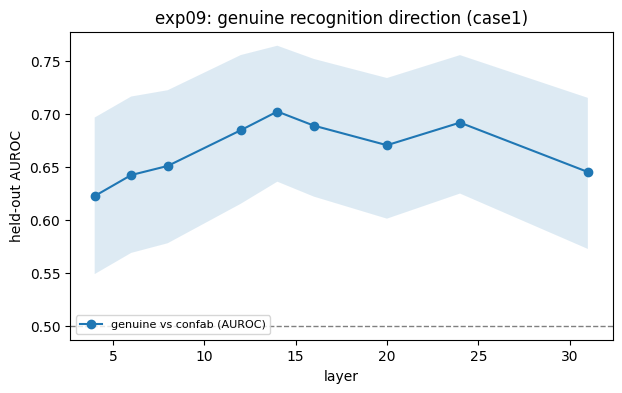

{'case': 'case1',
 'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'genuine_dir': array([[ 1.1082310e-03,  3.1595305e-04,  3.1998828e-03, ...,
         -1.6847197e-03, -4.2768568e-04,  5.7386607e-04],
        [-9.8847225e-04, -8.6906925e-04, -1.5083756e-03, ...,
          4.8449263e-05, -1.0428280e-03, -2.8785551e-04],
        [-4.9491413e-04,  2.2349507e-03,  2.4669953e-03, ...,
         -4.5226384e-03, -1.1597052e-03, -1.1956617e-03],
        ...,
        [ 1.2143999e-02,  9.8190010e-03, -1.1171773e-04, ...,
          8.4372461e-03, -6.4662201e-03, -6.6973120e-03],
        [ 1.0607671e-03,  3.6929399e-03,  1.1491552e-02, ...,
          7.4019730e-03,  8.9642406e-03, -1.2448549e-02],
        [-7.6927543e-03,  4.1359544e-02, -1.3764560e-02, ...,
          1.8966794e-02,  4.1644454e-02, -6.9284976e-02]],
       shape=(9, 4096), dtype=float32),
 'style_dir': array([[[-1.38138002e-02,  1.33933481e-02,  1.90988220e-02, ...,
          -3.19124176e-03,  2.20263144e-03, -9.26019903e-03],
      

In [14]:
@H.register("exp09", "Confabulation vs genuine recognition (decision-token)")
def exp09(ds, cfg, store):
    case = pick_self_case(ds, cfg); layers = ds.eval.layers
    df = H.eval_view(ds, cfg, cases=[case]).copy()
    df["chose_self"] = _chose_self(df)
    claims = df[df["chose_self"] & df["is_confident"]]
    H.report_cells(claims, ["case", "correct"], "exp09 confident self-claims (genuine vs confab)")
    arr, sub = H.stack_eval(ds, claims, H.DECISION)
    genuine_dir, auroc, lo, hi = None, [], [], []
    if len(arr):
        ok = (sub["correct"] == True).to_numpy(); bad = ~ok
        print(f"n correct-confident={int(ok.sum())}  n incorrect-confident(confab)={int(bad.sum())}")
        if ok.sum() >= 2 and bad.sum() >= 2:
            tr, te = H.split_by_groups(sub["base_trial_id"].to_numpy(), cfg.train_frac, cfg.seed)
            if (ok & tr).sum() >= 2 and (bad & tr).sum() >= 2:
                genuine_dir = H.mean_diff(arr[ok & tr], arr[bad & tr])
            else:
                genuine_dir = H.mean_diff(arr[ok], arr[bad]); te = np.ones(len(arr), bool)
            for li in range(len(layers)):
                c = H.bootstrap_ci(lambda y, s: H.auroc(y, s),
                                   (ok[te], H.proj_scalar(arr[te][:, li, :], genuine_dir[li])),
                                   n=cfg.n_bootstrap, seed=cfg.seed)
                auroc.append(c["point"]); lo.append(c["lo"]); hi.append(c["hi"])
    style = style_direction(ds, cfg)
    e2 = store.get("exp02"); rd = e2.get("pooled_read_dir") if isinstance(e2, dict) else None
    cos_style = ([float(H.cosine(genuine_dir[li], style[li][0])) for li in range(len(layers))]
                 if genuine_dir is not None and style is not None else [])
    cos_read = ([float(H.cosine(genuine_dir[li], rd[li])) for li in range(len(layers))]
                if genuine_dir is not None and rd is not None else [])
    d = H.art_dir(cfg, "exp09")
    if genuine_dir is not None:
        H.save_npz(d / "genuine_dir.npz", layers=np.array(layers), genuine_dir=genuine_dir,
                   style_dir=style if style is not None else np.zeros((0,)))
    H.save_json({"case": case, "layers": layers, "auroc": auroc, "cos_style": cos_style,
                 "cos_read": cos_read}, d / "exp09.json")
    return {"case": case, "layers": layers, "genuine_dir": genuine_dir, "style_dir": style,
            "auroc": auroc, "bands": (lo, hi), "cos_style": cos_style, "cos_read": cos_read}


def plot_exp09(res):
    if not res["auroc"]:
        print("exp09: too few confident self-claims to build a direction"); return
    H.plot_layer_curves(res["layers"], {"genuine vs confab (AUROC)": res["auroc"]},
                        ylabel="held-out AUROC", title=f"exp09: genuine recognition direction ({res['case']})",
                        hline=0.5, bands={"genuine vs confab (AUROC)": res["bands"]})


run_cell("exp09", plot_exp09)

## exp10 — Cross-task vector generalization (access)

**Question:** is the self-rec direction a **robust persona/self mechanism**, or is
it tied to one kind of task?

**Activations → measure.** Build the self/other probe on the text spans
(`TEXT*_MEAN`) of **one task family**, then test it two ways: **within** that
family (held-out trials) and **cross** family (trials from the other families).
The headline is the **transfer gap = within − cross** AUROC.

**Read it as.** A large gap ⇒ the direction is task/style-specific; a small gap ⇒
it transfers, i.e. a genuine persona/self mechanism. Few tasks per family in this
run, so n-per-cell is printed — treat small cells cautiously.

**Scale — reading the numbers.** Both curves are **AUROC** (0–1, chance 0.5). The
result is their **gap, measured in AUROC points**: a gap near **0** with both
curves well above 0.5 = the detector fully transfers across tasks (robust
mechanism); a gap of ~0.1–0.2 = partly task-specific; a gap approaching
(within − 0.5), i.e. cross-family dropping to ~0.5, = essentially no transfer (a
task/style trick). Compare the two curves layer by layer, and remember small task
counts inflate both the gap and its noise.



[exp10 spans by task family] grouping keys = ['task_category', 'is_self']; total n = 1241
task_category                 is_self
Near-twin role pairs          False      137
Suppressed semantic latent    False      136
Suppressed structural latent  False      128
Baseline floor                False       99
Suppressed epistemic latent   False       94
Near-twin role pairs          True        93
Calibration ceiling           False       90
Near-twin epistemic pair      False       83
Calibration medium            False       75
Suppressed semantic latent    True        73
Suppressed structural latent  True        68
Baseline floor                True        48
Calibration ceiling           True        41
Near-twin epistemic pair      True        34
Calibration medium            True        22
Suppressed epistemic latent   True        20
mean transfer gap (within - cross), over families: 0.133


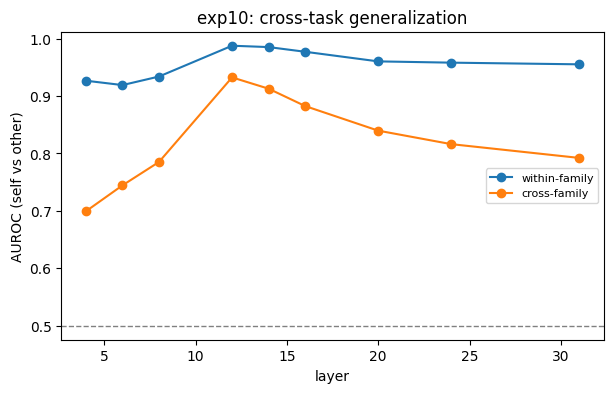

{'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'families': ['Near-twin role pairs',
  'Suppressed semantic latent',
  'Suppressed structural latent',
  'Baseline floor',
  'Calibration ceiling',
  'Near-twin epistemic pair',
  'Suppressed epistemic latent',
  'Calibration medium'],
 'results': {'Near-twin role pairs': {'within': [0.9578947368421054,
    0.956390977443609,
    0.9568922305764411,
    0.9914786967418546,
    0.9909774436090226,
    0.9919799498746867,
    0.9924812030075189,
    0.9909774436090226,
    0.9969924812030075],
   'cross': [0.6758401705835998,
    0.733796875724285,
    0.8398646456218422,
    0.9481435127242386,
    0.9361980253094146,
    0.9042414128772077,
    0.8951281694710982,
    0.8399851666434897,
    0.8705975061419368],
   'gap': [0.28205456625850556,
    0.22259410171932403,
    0.11702758495459897,
    0.043335184017616046,
    0.054779418299607974,
    0.08773853699747902,
    0.09735303353642066,
    0.15099227696553297,
    0.1263949750610707

In [15]:
@H.register("exp10", "Cross-task vector generalization (within vs cross family)")
def exp10(ds, cfg, store):
    case = pick_self_case(ds, cfg); layers = ds.eval.layers
    df = H.eval_view(ds, cfg, cases=[case])
    if "confident_correct" in df:
        df = df[df["confident_correct"]]
    V, tab = H.span_samples(ds, df)
    if len(V) == 0:
        print("exp10: no spans"); return {"layers": layers, "families": [], "results": {}}
    H.report_cells(tab, ["task_category", "is_self"], "exp10 spans by task family")
    counts = tab["task_category"].value_counts()
    fams = [f for f in counts.index if f and counts[f] >= 10]
    y = tab["is_self"].astype(int).to_numpy()
    results = {}
    for f in fams:
        infam = (tab["task_category"] == f).to_numpy(); idx = np.where(infam)[0]
        tri, tei = H.split_by_groups(tab.loc[infam, "base_trial_id"].to_numpy(), cfg.train_frac, cfg.seed)
        within, cross = [], []
        for li in range(len(layers)):
            X = V[:, li, :]
            within.append(H.logistic_auroc(X[idx[tri]], y[idx[tri]], X[idx[tei]], y[idx[tei]]))
            cross.append(H.logistic_auroc(X[infam], y[infam], X[~infam], y[~infam]))
        gap = [(w - c) if (w == w and c == c) else float("nan") for w, c in zip(within, cross)]
        results[f] = {"within": within, "cross": cross, "gap": gap}
    H.save_json({"case": case, "layers": layers, "families": fams, "results": results},
                H.art_dir(cfg, "exp10") / "exp10.json")
    if results:
        mg = np.nanmean([np.nanmean(results[f]["gap"]) for f in results])
        print(f"mean transfer gap (within - cross), over families: {mg:.3f}")
    return {"layers": layers, "families": fams, "results": results}


def plot_exp10(res):
    if not res["results"]:
        print("exp10: no families with enough spans"); return
    L = res["layers"]
    within = np.nanmean([res["results"][f]["within"] for f in res["results"]], axis=0)
    cross = np.nanmean([res["results"][f]["cross"] for f in res["results"]], axis=0)
    H.plot_layer_curves(L, {"within-family": within.tolist(), "cross-family": cross.tolist()},
                        ylabel="AUROC (self vs other)", title="exp10: cross-task generalization", hline=0.5)


run_cell("exp10", plot_exp10)

## exp11 — Cross-case mechanism comparison (control)

**Question:** does "**which text is mine**" use the **same mechanism** as "which
*other* persona wrote which" (third-party authorship)?

**Activations → measure.** Take the `DECISION`-token activation, remove the exp04
**nuisance directions** (A/B and text-position), and average per case → one cleaned
**centroid per case**. Compare cases by cosine between centroids per layer. Self
cases (1/3/7/12) are compared against the third-party case (5): **within-self**
similarity vs **self-vs-third** similarity.

**Read it as.** If self and third-party cases share geometry, authorship judgment
is one general mechanism; if self cases cluster apart, "mine" is special.

**Scale — reading the numbers.** The heatmap is cosine between case centroids,
−1 to +1 (the diagonal is 1.0 by construction — a case with itself). Off-diagonal
near **1** = those two cases use nearly the same decision geometry; near **0** =
different mechanisms; negative = opposed. The actual test is the comparison printed
below the plot: if **within-self cosine ≫ self-vs-third cosine**, recognising your
own text is mechanistically distinct from judging third-party authorship; if
they're similar, it's one shared mechanism.


cases present: ['case1', 'case10', 'case11', 'case12', 'case2', 'case3', 'case4', 'case5', 'case6', 'case8', 'case9']
self-vs-third-party centroid cosine: {'within_self': 0.9666053652763367, 'self_vs_third': 0.9526463945706686}


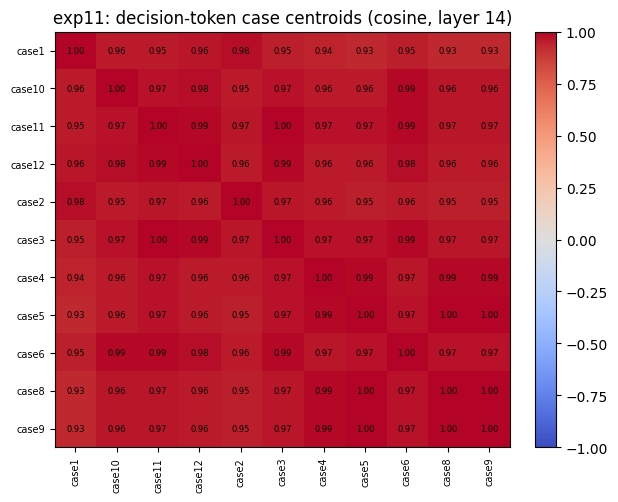

{'cases': ['case1',
  'case10',
  'case11',
  'case12',
  'case2',
  'case3',
  'case4',
  'case5',
  'case6',
  'case8',
  'case9'],
 'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'cosine_matrix': array([[0.99999988, 0.95619667, 0.95397902, 0.96167487, 0.97882056,
         0.95300996, 0.93786204, 0.93157232, 0.95239162, 0.93330801,
         0.93361086],
        [0.95619667, 1.00000012, 0.97466648, 0.98348546, 0.95350546,
         0.97398698, 0.96036184, 0.95957172, 0.98554176, 0.96318328,
         0.96388835],
        [0.95397902, 0.97466648, 0.99999994, 0.98592651, 0.96818316,
         0.9997831 , 0.97458124, 0.97058904, 0.98557144, 0.96773124,
         0.96760082],
        [0.96167487, 0.98348546, 0.98592651, 1.00000012, 0.9609282 ,
         0.98513126, 0.95999759, 0.9554736 , 0.97971416, 0.95698792,
         0.95732963],
        [0.97882056, 0.95350546, 0.96818316, 0.9609282 , 1.        ,
         0.9682312 , 0.95546657, 0.94955051, 0.96029085, 0.9483704 ,
         0.94793856],
   

In [16]:
@H.register("exp11", "Cross-case mechanism comparison (self vs third-party centroids)")
def exp11(ds, cfg, store):
    e4 = dep(store, "exp04"); layers = ds.eval.layers; nuis = e4["dirs"]
    df = H.eval_view(ds, cfg)
    present = sorted(df["case"].unique())
    cents = {}
    for c in present:
        arr, _ = H.stack_eval(ds, df[df["case"] == c], H.DECISION)
        if len(arr) == 0:
            continue
        clean = arr.copy()
        for li in range(len(layers)):
            for dv in nuis.values():
                clean[:, li, :] = H.project_out(clean[:, li, :], dv[li])
        cents[c] = clean.mean(0)
    cases = list(cents)
    print("cases present:", cases)
    li_rep = len(layers) // 2
    M = np.array([[float(H.cosine(cents[a][li_rep], cents[b][li_rep])) for b in cases] for a in cases])
    self_cases = [c for c in cases if c in ("case1", "case3", "case7", "case12")]
    third = [c for c in cases if c == "case5"]
    sep = None
    if self_cases and third:
        within = [M[cases.index(a), cases.index(b)] for a in self_cases for b in self_cases if a != b]
        across = [M[cases.index(a), cases.index(b)] for a in self_cases for b in third]
        sep = {"within_self": float(np.mean(within)) if within else float("nan"),
               "self_vs_third": float(np.mean(across)) if across else float("nan")}
        print("self-vs-third-party centroid cosine:", sep)
    H.save_npz(H.art_dir(cfg, "exp11") / "case_centroids.npz", layers=np.array(layers),
               cases=np.array(cases), cosine_matrix=M, **{f"cent_{c}": cents[c] for c in cases})
    H.save_json({"cases": cases, "rep_layer": layers[li_rep], "separation": sep},
                H.art_dir(cfg, "exp11") / "exp11.json")
    return {"cases": cases, "layers": layers, "cosine_matrix": M, "rep_layer": layers[li_rep],
            "cents": cents, "separation": sep}


def plot_exp11(res):
    if len(res["cases"]) < 2:
        print("exp11: <2 cases present"); return
    H.plot_heatmap(res["cosine_matrix"], xticks=res["cases"], yticks=res["cases"],
                   title=f"exp11: decision-token case centroids (cosine, layer {res['rep_layer']})",
                   annotate=True, cmap="coolwarm", vmin=-1, vmax=1)


run_cell("exp11", plot_exp11)

## exp12 — Persona switching during the task (depth, not access)

**Question (depth, not access):** while reading **someone else's** text, does the
active persona **drift toward** that other persona?

**Activations → measure.** On the **Other-authored** text span (`TEXT1_MEAN` /
`TEXT2_MEAN`, whichever the Other wrote), project the residual onto the
evaluator's **own** exp01 behavior vector vs the **Other's**. Then **drift = other
− own** projection, per layer.

**Read it as.** Positive, growing drift = the model is partly "becoming" the other
persona while reading it — a stability/depth readout, not a recognition score.
(True per-token drift would need a per-token capture this run lacks, so we use the
span-mean positions.)

**Scale — reading the numbers (this is the "what does 2.0 mean" case).** The y-axis
is a **raw projection difference** in residual-stream units — `(projection onto the
Other's fingerprint) − (projection onto the evaluator's own fingerprint)`. It has
**no fixed scale**: there's no "2.0 = a lot", and because residual-stream norms grow
with depth, the curve climbing toward ~2.0 in the **last layers is mostly that
norm growth, not 2× more drift**. What you can read:
- the **sign** — above the dashed zero line = leaning toward the Other; below =
  staying itself / leaning to own;
- the **shape vs zero** — does it rise above 0 specifically while reading the Other?
- **relative comparisons** at the same layer (e.g. across categories).

So treat "~2.0 in late layers" as "the drift-toward-Other signal is clearly
positive and largest deep in the network", **not** as a calibrated quantity. To
turn it into something scale-free you'd divide by the activation norm or report a
d′ against the within-condition scatter; this cell plots the raw difference.



[exp12 other-text-span projections] grouping keys = ['layer']; total n = 176868
layer
4     19652
6     19652
8     19652
12    19652
14    19652
16    19652
20    19652
24    19652
31    19652


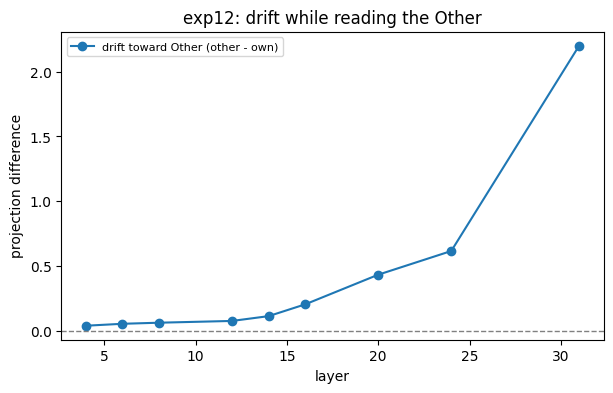

{'layers': [4, 6, 8, 12, 14, 16, 20, 24, 31],
 'table':         layer        evaluator            other  own_proj  other_proj  \
 0           4  archaic_speaker       child_five  1.689865    1.852412   
 1           6  archaic_speaker       child_five  2.190536    2.426876   
 2           8  archaic_speaker       child_five  2.231947    2.576623   
 3          12  archaic_speaker       child_five  3.662045    4.068915   
 4          14  archaic_speaker       child_five  3.559807    4.054904   
 ...       ...              ...              ...       ...         ...   
 176863     14       child_five  archaic_speaker  4.953231    6.043218   
 176864     16       child_five  archaic_speaker  5.268018    7.723202   
 176865     20       child_five  archaic_speaker  5.411922   10.037600   
 176866     24       child_five  archaic_speaker  9.806614   16.110947   
 176867     31       child_five  archaic_speaker  4.653061   16.156540   
 
             drift  
 0        0.162547  
 1        0.2

In [17]:
@H.register("exp12", "Persona switching during the task (drift toward Other)")
def exp12(ds, cfg, store):
    e1 = dep(store, "exp01"); behav = e1["behavior"]; layers = ds.gen.layers
    present = set(ds.eval_meta["case"].unique()) if not ds.eval_meta.empty else set()
    cases = [c for c in ["case5", "case8", "case9", "case3", "case12", "case7"] if c in present]
    df = H.eval_view(ds, cfg, cases=cases) if cases else H.eval_view(ds, cfg)
    nL = min(len(layers), min((behav[p].shape[0] for p in behav), default=0))
    rows = []
    for r in df.itertuples(index=False):
        ev = r.evaluator_persona
        if ev not in behav:
            continue
        for slot, cap, srccol in (("text1", H.TEXT1_MEAN, "text1_source_persona"),
                                  ("text2", H.TEXT2_MEAN, "text2_source_persona")):
            src = getattr(r, srccol, None)
            if src is None or src == ev or src not in behav:
                continue
            v = ds.eval.vector(r.id, cap)
            if v is None:
                continue
            for li in range(nL):
                own = float(v[li] @ H.unit(behav[ev][li])); oth = float(v[li] @ H.unit(behav[src][li]))
                rows.append({"layer": layers[li], "evaluator": ev, "other": src,
                             "own_proj": own, "other_proj": oth, "drift": oth - own})
    out = pd.DataFrame(rows)
    H.report_cells(out, ["layer"], "exp12 other-text-span projections", max_rows=12)
    H.save_df(out, H.art_dir(cfg, "exp12") / "switching.parquet") if not out.empty else None
    return {"layers": layers[:nL], "table": out}


def plot_exp12(res):
    out = res["table"]
    if out.empty:
        print("exp12: no other-authored spans (need described/2-text cases)"); return
    g = out.groupby("layer").agg(drift=("drift", "mean")).reset_index()
    H.plot_layer_curves(g["layer"].tolist(), {"drift toward Other (other - own)": g["drift"].tolist()},
                        ylabel="projection difference", title="exp12: drift while reading the Other", hline=0.0)


run_cell("exp12", plot_exp12)

## exp13 — Deceptive / hidden-goal clustering (depth)

**Question (depth):** do **hidden-goal / deceptive** personas (sandbagger,
sycophant) occupy a shared region of activation space regardless of the surface
text they produce?

**Activations → measure.** Cluster the exp01 **persona-behavior vectors** —
cosine similarity at a mid layer, then hierarchical clustering. This uses **no**
recognition or accuracy scores at all, only the behavior fingerprints, so any
grouping comes purely from how the personas process.

**Read it as.** Confound personas landing together — while the non-deceptive
**historians** stay in a separate control cluster — is evidence of a shared
hidden-goal representation (and rules out "any grouping looks like this").

**Scale — reading the numbers.** The heatmap is persona×persona cosine (−1 to +1),
rows/columns reordered so cluster members sit together. **Warm blocks on the
diagonal** = groups of personas with similar fingerprints (cosine toward 1); cool
off-diagonal = dissimilar. The cluster labels `c0, c1, …` in the tick labels are
just **names with no order or magnitude**. The result is qualitative: do the
confounds share one warm block while the historians form a separate one? A washed-
out map (everything mildly warm) means fingerprints aren't cleanly separable here.


confound personas: ['sandbagger', 'sycophant'] -> clusters [1, 1]
historian control: ['historian_american', 'historian_eastasian'] -> clusters [1, 1]


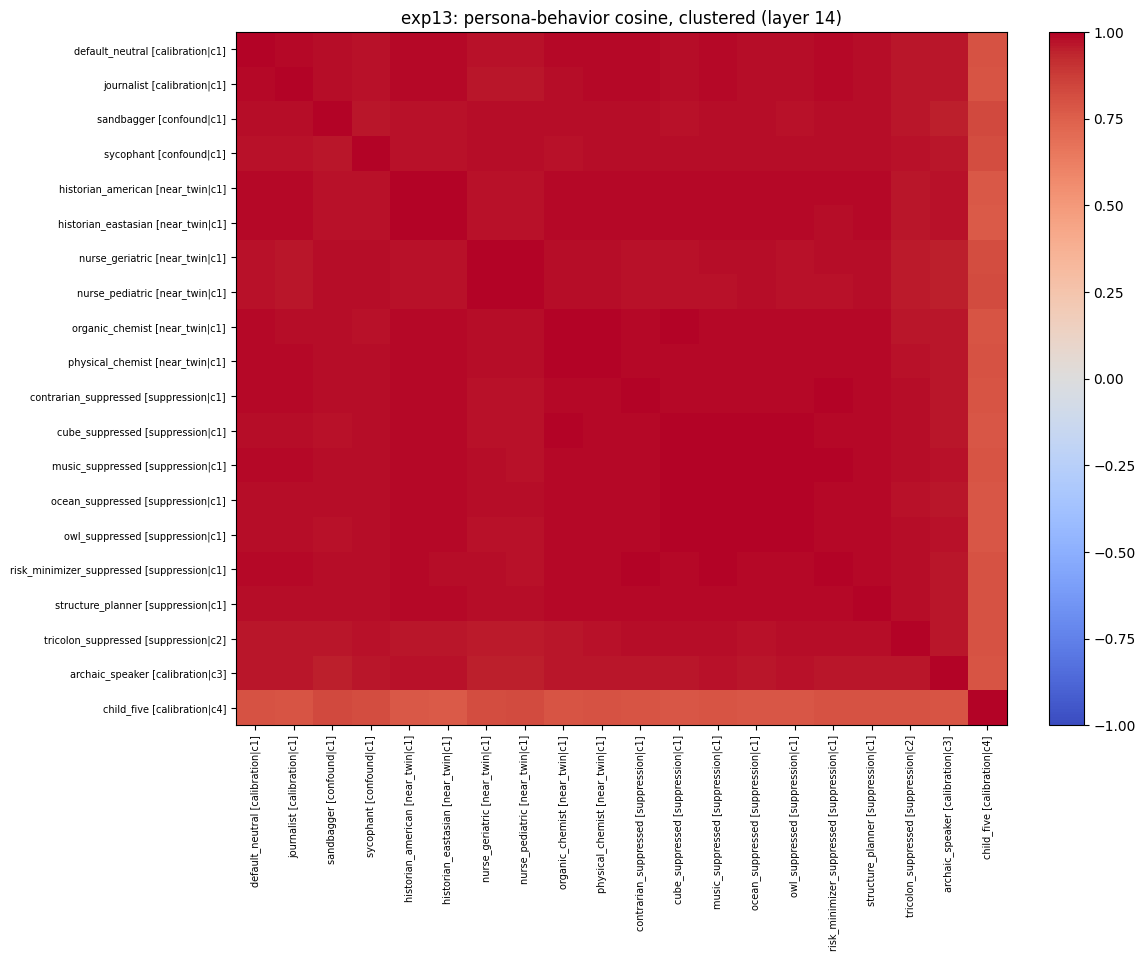

{'personas': ['archaic_speaker',
  'child_five',
  'contrarian_suppressed',
  'cube_suppressed',
  'default_neutral',
  'historian_american',
  'historian_eastasian',
  'journalist',
  'music_suppressed',
  'nurse_geriatric',
  'nurse_pediatric',
  'ocean_suppressed',
  'organic_chemist',
  'owl_suppressed',
  'physical_chemist',
  'risk_minimizer_suppressed',
  'sandbagger',
  'structure_planner',
  'sycophant',
  'tricolon_suppressed'],
 'cosine': array([[1.        , 0.7899375 , 0.9667638 , 0.96854126, 0.96371317,
         0.9712833 , 0.9720795 , 0.9647887 , 0.969716  , 0.94878113,
         0.9469799 , 0.9681251 , 0.9638412 , 0.97242373, 0.9663173 ,
         0.9637843 , 0.9456371 , 0.9679593 , 0.9638026 , 0.9630552 ],
        [0.7899375 , 1.0000001 , 0.7898953 , 0.78500664, 0.80367684,
         0.7777988 , 0.77020323, 0.7917477 , 0.7904825 , 0.8176316 ,
         0.8243427 , 0.7885724 , 0.79528785, 0.7819727 , 0.79789376,
         0.79925406, 0.8282159 , 0.8007002 , 0.8144141 , 0.7982

In [18]:
@H.register("exp13", "Hidden-goal / deceptive clustering of persona behavior vectors")
def exp13(ds, cfg, store):
    e1 = dep(store, "exp01"); behav = e1["behavior"]; layers = e1["layers"]
    personas = list(behav)
    if len(personas) < 3:
        print("exp13: too few personas"); return {"personas": personas}
    li = len(layers) // 2
    M = np.stack([behav[p][li] for p in personas])
    C = H.cosine_matrix(M)
    coarse = {p: H.coarse_category(ds.persona_category.get(p, "")) for p in personas}
    try:
        from scipy.cluster.hierarchy import linkage, fcluster
        from scipy.spatial.distance import squareform
        D = 1.0 - C; np.fill_diagonal(D, 0.0); D = (D + D.T) / 2
        Z = linkage(squareform(D, checks=False), method="average")
        labels = fcluster(Z, t=4, criterion="maxclust")
    except Exception as e:
        from sklearn.cluster import KMeans
        print("scipy unavailable, KMeans fallback:", e)
        labels = KMeans(n_clusters=min(4, len(personas)), n_init=10, random_state=cfg.seed).fit_predict(H.unit(M))
    cluster = dict(zip(personas, [int(x) for x in labels]))
    # do the confounds land together, separate from the historian control?
    conf = [p for p in personas if coarse[p] == "confound"]
    hist = [p for p in personas if "historian" in p]
    print("confound personas:", conf, "-> clusters", [cluster[p] for p in conf])
    print("historian control:", hist, "-> clusters", [cluster[p] for p in hist])
    H.save_npz(H.art_dir(cfg, "exp13") / "behavior_clustering.npz", personas=np.array(personas),
               cosine=C, labels=np.array(labels), rep_layer=np.array([layers[li]]))
    H.save_json({"personas": personas, "cluster": cluster, "coarse": coarse, "rep_layer": layers[li]},
                H.art_dir(cfg, "exp13") / "exp13.json")
    return {"personas": personas, "cosine": C, "cluster": cluster, "coarse": coarse, "rep_layer": layers[li]}


def plot_exp13(res):
    if "cosine" not in res:
        return
    personas = res["personas"]
    order = sorted(range(len(personas)), key=lambda i: (res["cluster"][personas[i]], res["coarse"][personas[i]]))
    labs = [f"{personas[i]} [{res['coarse'][personas[i]]}|c{res['cluster'][personas[i]]}]" for i in order]
    M = res["cosine"][np.ix_(order, order)]
    H.plot_heatmap(M, xticks=labs, yticks=labs, cmap="coolwarm", vmin=-1, vmax=1,
                   title=f"exp13: persona-behavior cosine, clustered (layer {res['rep_layer']})")


run_cell("exp13", plot_exp13)

## exp14 — Steer / color / project out (causal; runs last)

**Question (causal):** does the candidate self-rec direction **cause** the
authorship judgment, or just correlate with it? Everything above is observational;
this is the test that intervenes.

**Activations → measure.** Re-run **real forward passes** with residual-stream
edits along the exp02 self-rec direction:

- **steer** — *add* the direction at the `DECISION` token, sweeping layer ×
  multiplier (α)
- **project out** — *remove* the direction at every position

For each, measure the change in the **probability assigned to the correct A/B
answer** versus the unedited run.

**Read it as.** Recognition **collapsing when the direction is projected out** is
the primary causal result; a graded steer effect (more α → more "mine") confirms
the direction is doing the work.

**Scale — reading the numbers (a real probability, unlike exp06/07/12).** The
y-axis is the probability mass the model puts on the **correct** A/B answer: 0–1,
where **0.5 = a coin flip** between the two letters and ~1.0 = confident and right.
The dashed line is the **unedited baseline**; what matters is the **gap from it**:
- *project-out* dropping the curve toward ~0.5 (or below) = removing the direction
  **destroys** recognition — the key causal result;
- *steering* — the correct-prob moving smoothly as α grows (and flipping sign with
  α's sign) shows the direction actively pushes the judgment.
A flat curve sitting on the baseline at every layer = that layer's edit does
nothing causal.

**Requires** `cfg.enable_steering=True`, a GPU with the model loaded, and the local
eval trial table (`results/text_evaluations/<task>/<run_name>/*.jsonl`) for the
exact prompts. It reuses the evaluation's own model/hook infrastructure
(`HFBackend`, `core.activation_capture.decoder_layers`) — nothing is rebuilt.


In [19]:
@H.register("exp14", "Steer / color / project out (causal)")
def exp14(ds, cfg, store):
    if not cfg.enable_steering:
        print("exp14 is causal: set cfg.enable_steering=True on a GPU box with the model.")
        return {"skipped": True, "reason": "enable_steering is False"}
    e2 = dep(store, "exp02"); pooled, layers, case = e2["pooled_read_dir"], e2["layers"], e2["case"]
    if pooled is None:
        return {"skipped": True, "reason": "no self-rec direction from exp02"}
    tt = H.load_trial_table(cfg)
    if tt.empty:
        print("no local trial table under results/text_evaluations/<task>/<run_name>/ — needed for prompts.")
        return {"skipped": True, "reason": "no trial table"}
    from core.backends.hf_backend import HFBackend
    from core.run_utils import resolve_dtype
    backend = HFBackend(cfg.model_name, torch_dtype=resolve_dtype(None))

    sub = tt[(tt["case_id"] == case)].dropna(subset=["prompt_text"])
    sub = sub.head(cfg.dry_run_max_per_cell if cfg.dry_run else 60)
    if sub.empty:
        return {"skipped": True, "reason": f"no {case} rows in trial table"}
    baseline = []
    for r in sub.itertuples(index=False):
        pr = H.steered_choice_probs(backend, _messages_from_row(r), ["A", "B"], [])
        baseline.append(pr.get(r.correct_answer, 0.0))
    base_mean = float(np.mean(baseline))

    alphas = [-8.0, -4.0, 4.0, 8.0]
    steer_rows, proj_rows = [], []
    for li, l in enumerate(layers):
        for alpha in alphas:
            ds_pc = []
            for r in sub.itertuples(index=False):
                edits = [{"layer": l, "vec": pooled[li], "alpha": alpha, "mode": "add",
                          "positions": (lambda seq: [seq - 1])}]  # steer the decision token
                pr = H.steered_choice_probs(backend, _messages_from_row(r), ["A", "B"], edits)
                ds_pc.append(pr.get(r.correct_answer, 0.0))
            steer_rows.append({"layer": l, "alpha": alpha, "mean_prob_correct": float(np.mean(ds_pc)),
                               "delta_vs_baseline": float(np.mean(ds_pc) - base_mean), "n": len(ds_pc)})
        ds_po = []
        for r in sub.itertuples(index=False):
            edits = [{"layer": l, "vec": pooled[li], "alpha": 0.0, "mode": "project_out", "positions": None}]
            pr = H.steered_choice_probs(backend, _messages_from_row(r), ["A", "B"], edits)
            ds_po.append(pr.get(r.correct_answer, 0.0))
        proj_rows.append({"layer": l, "mean_prob_correct": float(np.mean(ds_po)),
                          "delta_vs_baseline": float(np.mean(ds_po) - base_mean), "n": len(ds_po)})
    steer = pd.DataFrame(steer_rows); proj = pd.DataFrame(proj_rows)
    H.save_df(steer, H.art_dir(cfg, "exp14") / "steer_sweep.parquet")
    H.save_df(proj, H.art_dir(cfg, "exp14") / "project_out_sweep.parquet")
    peak = steer.iloc[steer["delta_vs_baseline"].abs().idxmax()] if len(steer) else None
    print(f"baseline mean prob(correct) = {base_mean:.3f}")
    if peak is not None:
        print(f"peak steer effect: layer {int(peak.layer)}, alpha {peak.alpha} -> "
              f"delta {peak.delta_vs_baseline:+.3f}")
    return {"case": case, "baseline": base_mean, "steer": steer, "project_out": proj, "layers": layers}


def plot_exp14(res):
    if res.get("skipped"):
        print("exp14 skipped:", res.get("reason")); return
    proj = res["project_out"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].axhline(res["baseline"], ls="--", c="grey", lw=1, label="baseline")
    for alpha, g in res["steer"].groupby("alpha"):
        ax[0].plot(g["layer"], g["mean_prob_correct"], marker="o", label=f"add a={alpha}")
    ax[0].set_title("exp14: steer at decision token"); ax[0].set_xlabel("layer")
    ax[0].set_ylabel("mean prob(correct)"); ax[0].legend(fontsize=8)
    ax[1].axhline(res["baseline"], ls="--", c="grey", lw=1, label="baseline")
    ax[1].plot(proj["layer"], proj["mean_prob_correct"], marker="o", c="crimson", label="project out")
    ax[1].set_title("exp14: project out self-rec direction"); ax[1].set_xlabel("layer")
    ax[1].set_ylabel("mean prob(correct)"); ax[1].legend(fontsize=8)
    fig.tight_layout()


run_cell("exp14", plot_exp14)

exp14 is causal: set cfg.enable_steering=True on a GPU box with the model.
exp14 skipped: enable_steering is False


{'skipped': True, 'reason': 'enable_steering is False'}

## Run the whole suite

Runs every registered experiment in canonical order (exp01 + exp04 first; exp14
last, skipped unless `cfg.enable_steering`). Each result is cached in `STORE` so
later experiments consume earlier ones. Flip `cfg.dry_run = False` first for a
full run.

In [20]:
if "ds" in globals() and ds is not None:
    STORE = H.run_suite(ds, cfg, store=STORE)
    print("\nfinished:", [k for k in H.ORDER if k in STORE and not (isinstance(STORE.get(k), dict) and STORE[k].get('skipped'))])


=== exp01: Persona vectors: behavior (neutral gen) + prompt-state  [enabling] ===

=== exp04: Nuisance directions (A/B, text-position) at the decision token  [enabling] ===

=== exp02: Self-recognition vector (read-side + decision), style-removed variant  [access] ===

=== exp03: Behavioral recognition baseline (accuracy/confidence by case x condition x category)  [control] ===

=== exp05: Self-rec vectors: shared vs distinct + alignment to persona behavior  [access] ===

=== exp06: Self-prior (pre-text) vs evidence-driven (decision) projection  [access] ===

=== exp07: Online vs decision-time recognition (layer x token map)  [access] ===

=== exp08: Probes: author vs persona-identity vs task vs position by layer  [access] ===

=== exp09: Confabulation vs genuine recognition (decision-token)  [access] ===

=== exp10: Cross-task vector generalization (within vs cross family)  [access] ===

=== exp11: Cross-case mechanism comparison (self vs third-party centroids)  [control] ===

=== ex